# 02 · RL Portfolio Environment

Gymnasium-compatible environment for PPO-based portfolio optimization.
One environment per risk profile (conservative / balanced / aggressive).

v2 architectural improvements:
  - VecEnv (DummyVecEnv) for richer rollout diversity during training
  - Multi-episode evaluation: all valid start indices in each eval window
  - Block bootstrap confidence intervals for Sharpe and annualized return
  - Walk-forward retraining: expanding windows across 2015-2026
  - Rolling evaluation windows with per-fold metric aggregation
  - EGX30 market regime signal in observation (MA20/MA60-1, from notebook 01)
  - CVaR reported as per-period (not annualized) — interpretable tail metric
  - Proportional timesteps per fold: more training data → more steps

## 1. Imports

In [1]:
from pathlib import Path
import json
import subprocess
import sys
import numpy as np
import pandas as pd
import torch
from scipy import stats
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import (
    EvalCallback,
    StopTrainingOnNoModelImprovement,
    BaseCallback,
)
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor

## 2. Configuration

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR      = Path("../../")
DATA_DIR      = BASE_DIR / "data"
TENSORS_DIR   = DATA_DIR / "processed/tensors"
METADATA_DIR  = DATA_DIR / "processed/metadata"

CLUSTERING_PATH  = BASE_DIR / "outputs/volatility_clustering/asset_classification.csv"
LGBM_PRED_PATH   = BASE_DIR / "outputs/lgbm_forecasting/lgbm_predictions.csv"
MARKET_DATA_PATH = BASE_DIR / "src/ingestion/cache/market_data.csv"
RRFR_SCRIPT_PATH = BASE_DIR / "src/ingestion/EGX30_RRFR.py"

In [3]:
# ── Version and profile ───────────────────────────────────────────────────────
VERSION      = "v4"
RISK_PROFILE = "balanced"

In [4]:
# ── Episode structure ─────────────────────────────────────────────────────────
EPISODE_LENGTH   = 24       # steps per training episode (24 x 21 = 504 trading days)
REBALANCE_DAYS   = 21       # trading days per step
PERIODS_PER_YEAR = 252 / 21  # 12 rebalancing periods per year

In [5]:
# ── Action space constraints ──────────────────────────────────────────────────
MAX_CASH_WEIGHT  = 0.30
MAX_STOCK_WEIGHT = 0.20
MIN_STOCK_WEIGHT = 0.0

In [6]:
# ── Transaction costs ─────────────────────────────────────────────────────────
BASE_TRANSACTION_COST = 0.0064
MAX_TRANSACTION_COST  = 0.015

In [7]:
# ── VecEnv parallelism ────────────────────────────────────────────────────────
N_ENVS = 4

In [8]:
# ── Walk-forward configuration ────────────────────────────────────────────────
# Expanding window: training always starts from dataset start (2015).
# Each fold adds one year to the training window.
WALK_FORWARD_FOLDS = [
    {"name": "fold_1", "train_end": "2019-12-31", "val_end": "2020-12-31", "test_end": "2021-12-31"},
    {"name": "fold_2", "train_end": "2020-12-31", "val_end": "2021-12-31", "test_end": "2022-12-31"},
    {"name": "fold_3", "train_end": "2021-12-31", "val_end": "2022-12-31", "test_end": "2023-12-31"},
    {"name": "fold_4", "train_end": "2022-12-31", "val_end": "2023-12-31", "test_end": "2025-12-31"},
]

# ── Proportional timesteps ────────────────────────────────────────────────────
# Fold 1 is the baseline. Later folds have more training data and receive
# proportionally more timesteps so each data point gets equal training exposure.
BASE_TIMESTEPS  = 2_500_000   # timesteps for fold_1
# Actual per-fold timesteps are computed in the training loop after loading
# split indices, using: int(BASE_TIMESTEPS * n_train_days / fold_1_train_days)

In [9]:
# ── Multi-episode evaluation ──────────────────────────────────────────────────
MAX_EVAL_EPISODES = 50

# ── Block bootstrap ───────────────────────────────────────────────────────────
N_BOOTSTRAP      = 2000
BOOTSTRAP_BLOCK  = 3      # block size in rebalancing steps (3 x 21 = 63 days)
CONFIDENCE_LEVEL = 0.95

In [10]:
# ── PPO hyperparameters ───────────────────────────────────────────────────────
PPO_PARAMS = {
    "policy":          "MlpPolicy",
    "learning_rate":   3e-4,
    "n_steps":         2048,
    "batch_size":      64,
    "n_epochs":        10,
    "gamma":           0.995,
    "gae_lambda":      0.95,
    "clip_range":      0.2,
    "ent_coef":        0.01,
    "vf_coef":         0.5,
    "max_grad_norm":   0.5,
    "verbose":         0,
    "policy_kwargs": {
        "net_arch":      [256, 256, 256],
        "activation_fn": __import__("torch.nn", fromlist=["Tanh"]).Tanh,
    },
}

In [11]:
REWARD_CONFIGS = {
    "conservative": {
        "return_weight":    1.0,
        "turnover_penalty": 0.002,
        "downside_penalty": 2.0,
        "drawdown_penalty": 3.0,
        "hhi_penalty":      0.8,
        "cash_penalty":     0.5,   # conservative: mild incentive to deploy in bull
    },
    "balanced": {
        "return_weight":    1.0,
        "turnover_penalty": 0.002,
        "downside_penalty": 0.8,
        "drawdown_penalty": 1.0,
        "hhi_penalty":      0.3,
        "cash_penalty":     2.0,   # ← new: penalize excess cash in bull markets
    },
    "aggressive": {
        "return_weight":    1.0,
        "turnover_penalty": 0.002,
        "downside_penalty": 0.0,
        "drawdown_penalty": 0.0,
        "hhi_penalty":      0.1,
        "cash_penalty":     3.0,   # aggressive: strong incentive to stay invested
    },
}

In [12]:
# ── Plot palette ──────────────────────────────────────────────────────────────
PALETTE = {
    "primary":   "#2c7bb6",
    "secondary": "#d7191c",
    "tertiary":  "#fdae61",
    "accent":    "#abd9e9",
    "train":     "#2c7bb6",
    "val":       "#fdae61",
    "test":      "#2ca25f",
    "alert":     "#d7191c",
}

## 3. Risk-Free Rate (CBE CONIA)

In [13]:
print("Fetching risk-free rate from CBE...")

try:
    result = subprocess.run(
        ["python", str(RRFR_SCRIPT_PATH)],
        capture_output=True, text=True, timeout=60
    )
    if result.returncode != 0:
        raise RuntimeError(result.stderr)

    market_df = pd.read_csv(MARKET_DATA_PATH)
    market_df["conia_date"] = pd.to_datetime(market_df["conia_date"])
    latest_row = market_df.sort_values("conia_date").iloc[-1]

    ANNUAL_RISK_FREE_RATE = float(latest_row["conia_value"])
    conia_date            = latest_row["conia_date"].date()
    print(f"✓ CONIA loaded : {ANNUAL_RISK_FREE_RATE*100:.2f}% (as of {conia_date})")

except Exception as e:
    ANNUAL_RISK_FREE_RATE = 0.21
    print(f"⚠ RRFR script failed: {e}")
    print(f"  Using fallback rate: {ANNUAL_RISK_FREE_RATE*100:.2f}%")

PERIOD_RISK_FREE_RATE = (1 + ANNUAL_RISK_FREE_RATE) ** (21 / 252) - 1
print(f"  Annual rate     : {ANNUAL_RISK_FREE_RATE*100:.2f}%")
print(f"  Per-period rate : {PERIOD_RISK_FREE_RATE*100:.4f}%  (21-day equivalent)")

Fetching risk-free rate from CBE...


⚠ RRFR script failed: Traceback (most recent call last):
  File "C:\Users\youssef\Desktop\Portfolio_Personalization\src\ingestion\EGX30_RRFR.py", line 18, in <module>
    from selenium import webdriver
ModuleNotFoundError: No module named 'selenium'

  Using fallback rate: 21.00%
  Annual rate     : 21.00%
  Per-period rate : 1.6012%  (21-day equivalent)


## 4. Load Artifacts

In [14]:
feature_tensor = torch.load(
    TENSORS_DIR / "feature_tensor.pt", weights_only=False
).numpy()

returns_tensor = torch.load(
    TENSORS_DIR / "returns_tensor.pt", weights_only=False
).numpy()

mask_tensor = torch.load(
    TENSORS_DIR / "mask_tensor.pt", weights_only=False
).numpy()

# ── Market regime signal ──────────────────────────────────────────────────────
# Shape: [T] — normalized EGX30 MA(20)/MA(60)-1, lagged 1 day.
# Produced by notebook 01. One scalar per day, same for all stocks.
# > 0 = bull trend, < 0 = bear trend, 0 = neutral.
market_signal = torch.load(
    TENSORS_DIR / "market_signal.pt", weights_only=False
).numpy()

In [15]:
with open(METADATA_DIR / "feature_names.json") as f:
    feature_names = json.load(f)

with open(METADATA_DIR / "split_indices.json") as f:
    global_split_indices = json.load(f)

with open(METADATA_DIR / "meta.json") as f:
    meta = json.load(f)

with open(METADATA_DIR / "date_index.json") as f:
    date_index = json.load(f)

with open(METADATA_DIR / "market_signal_stats.json") as f:
    market_signal_stats = json.load(f)

In [16]:
print(f"Feature tensor  : {feature_tensor.shape}  (T, N_stocks, N_features)")
print(f"Returns tensor  : {returns_tensor.shape}  (T, N_stocks)")
print(f"Mask tensor     : {mask_tensor.shape}  (T, N_stocks)")
print(f"Market signal   : {market_signal.shape}  (T, 3)  "
      f"egx30=[{market_signal[:,0].min():.3f}, {market_signal[:,0].max():.3f}]  "
      f"conia=[{market_signal[:,1].min():.3f}, {market_signal[:,1].max():.3f}]  "
      f"usdegp=[{market_signal[:,2].min():.3f}, {market_signal[:,2].max():.3f}]")
print(f"Date range      : {date_index[0]} to {date_index[-1]}")
print(f"Tickers         : {meta['n_stocks']}")
print(f"Market signal   : {meta.get('market_signal', 'egx30_ma_ratio + macro')}")

assert market_signal.shape[0] == feature_tensor.shape[0], \
    "market_signal T dimension must match feature_tensor T dimension"
assert not np.isnan(market_signal).any(), \
    "market_signal contains NaN — check notebook 01 trimming"
assert market_signal.shape[1] == 3, \
    f"Expected 3 market signals, got {market_signal.shape[1]}"

print(f"\nAll tensors loaded and validated.")

Feature tensor  : (1940, 54, 9)  (T, N_stocks, N_features)
Returns tensor  : (1940, 54)  (T, N_stocks)
Mask tensor     : (1940, 54)  (T, N_stocks)
Market signal   : (1940, 3)  (T, 3)  egx30=[-2.692, 4.679]  conia=[0.000, 0.000]  usdegp=[0.000, 0.000]
Date range      : 2018-04-19 to 2026-04-22
Tickers         : 54
Market signal   : [egx30_ma_ratio MA20/MA60-1, conia_delta 60d, inflation_delta 60d]

All tensors loaded and validated.


In [17]:
# Build date-to-index lookup for walk-forward fold construction
date_to_idx = {d: i for i, d in enumerate(date_index)}

## 5. Volatility Clustering Universe Filter

In [18]:
all_tickers = meta["tickers"]

if CLUSTERING_PATH.exists():
    cluster_df = pd.read_csv(CLUSTERING_PATH)
    cluster_df = cluster_df[cluster_df["ticker"].isin(all_tickers)].copy()
    cluster_df = cluster_df.set_index("ticker")

    print(f"Clustering file : {CLUSTERING_PATH}")
    print(f"Risk profile breakdown:")
    print(cluster_df["risk_profile"].value_counts().to_string())

    universe_tickers = sorted([
        t for t in cluster_df[cluster_df["risk_profile"] == RISK_PROFILE].index
        if t in all_tickers
    ])
    print(f"\nProfile  : {RISK_PROFILE}")
    print(f"Universe : {len(universe_tickers)} stocks")
    print(f"Tickers  : {universe_tickers}")
else:
    print("⚠ Clustering file not found — using all tickers")
    universe_tickers = sorted(all_tickers)

universe_indices = [all_tickers.index(t) for t in universe_tickers]
REL_VOL_IDX = feature_names.index("rel_volume")

⚠ Clustering file not found — using all tickers


## 6. PortfolioEnv Class

In [19]:
class PortfolioEnv(gym.Env):
    """
    Gymnasium-compatible portfolio optimization environment.

    Observation vector layout:
        [0 : N*F]        per-stock features, flattened (N x F numbers)
        [N*F : N*F+N]    current stock weights          (N numbers)
        [N*F+N]          current cash weight             (1 number)
        [N*F+N+1]        EGX30 market regime signal      (1 number)  ← NEW
        Total: N*F + N + 1 + 1

    The market regime signal (EGX30 MA20/MA60 - 1, normalized, lagged 1d)
    allows the agent to condition cash allocation on market trend:
      > 0 (bull): incentive to deploy cash into stocks
      < 0 (bear): incentive to hold or increase cash

    Previous weights (stock + cash) are included in the state so the agent
    is aware of its current holdings when deciding new allocations — essential
    for turnover-aware rebalancing.
    """

    def __init__(
        self,
        feature_tensor,
        returns_tensor,
        mask_tensor,
        market_signal,
        universe_indices,
        split_indices,
        risk_profile,
        feature_names,
        mode="train",
        episode_length=24,
        rebalance_days=21,
        silent=False,
    ):
        super().__init__()

        self.feature_tensor   = feature_tensor
        self.returns_tensor   = returns_tensor
        self.mask_tensor      = mask_tensor
        self.market_signal    = market_signal   # shape [T]
        self.universe_indices = universe_indices
        self.feature_names    = feature_names
        self.risk_profile     = risk_profile
        self.mode             = mode
        self.episode_length   = episode_length
        self.rebalance_days   = rebalance_days

        self.N = len(universe_indices)
        self.F = feature_tensor.shape[2]
        self.T = feature_tensor.shape[0]

        self.reward_cfg  = REWARD_CONFIGS[risk_profile]
        self.rel_vol_idx = REL_VOL_IDX

        rows_needed = episode_length * rebalance_days
        available   = split_indices[mode]
        self.valid_starts = [
            i for i in available
            if i + rows_needed < self.T
        ]

        obs_dim = self.N * self.F + self.N + 1 + 3 # 3 market signals
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-10.0, high=10.0, shape=(self.N + 1,), dtype=np.float32
        )

        if not silent:
            print(f"PortfolioEnv [{mode}] : {self.N} stocks | "
                  f"{len(self.valid_starts)} valid starts | "
                  f"obs=({obs_dim},) = {self.N}x{self.F} features "
                  f"+ {self.N} stock weights + 1 cash + 1 market signal")

        self.current_step    = 0
        self.start_idx       = 0
        self.current_weights = np.zeros(self.N + 1, dtype=np.float32)
        self.portfolio_value = 1.0
        self.peak_value      = 1.0
        self.episode_returns = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        if options is not None and "start_idx" in options:
            self.start_idx = options["start_idx"]
        elif self.mode == "train":
            self.start_idx = int(np.random.choice(self.valid_starts))
        else:
            self.start_idx = self.valid_starts[0]

        self.current_step    = 0
        self.portfolio_value = 1.0
        self.peak_value      = 1.0
        self.episode_returns = []
        self.current_weights = np.full(
            self.N + 1, 1.0 / (self.N + 1), dtype=np.float32
        )

        return self._get_observation(), {}

    def _get_observation(self):
        day_idx = self.start_idx + self.current_step * self.rebalance_days

        # Per-stock features (masked for unavailable stocks)
        stock_features = self.feature_tensor[day_idx, self.universe_indices, :]
        stock_mask     = self.mask_tensor[day_idx, self.universe_indices]
        stock_features = stock_features * stock_mask[:, np.newaxis]

        # Market regime signal: scalar at this day
        regime_signal = self.market_signal[day_idx].astype(np.float32)  # shape [3]

        return np.concatenate([
            stock_features.flatten(),    # N * F values
            self.current_weights[:-1],   # N stock weights (previous step)
            self.current_weights[-1:],   # 1 cash weight   (previous step)
            regime_signal,               # 1 market regime signal  ← NEW
        ]).astype(np.float32)

    def _apply_position_limits(self, weights, stock_mask):
        stock_weights = weights[:-1].copy()
        for _ in range(10):
            if not (stock_weights > MAX_STOCK_WEIGHT).any():
                break
            for i in range(len(stock_weights)):
                if stock_weights[i] > MAX_STOCK_WEIGHT:
                    excess           = stock_weights[i] - MAX_STOCK_WEIGHT
                    stock_weights[i] = MAX_STOCK_WEIGHT
                    eligible = np.array([
                        j for j in range(len(stock_weights))
                        if j != i and stock_mask[j] == 1
                        and stock_weights[j] < MAX_STOCK_WEIGHT
                    ])
                    if len(eligible) > 0:
                        s = stock_weights[eligible].sum()
                        if s > 1e-8:
                            stock_weights[eligible] += excess * (
                                stock_weights[eligible] / s
                            )
                        else:
                            stock_weights[eligible] += excess / len(eligible)
                    else:
                        weights[-1] += excess
        weights[:-1] = stock_weights
        return weights

    def _liquidity_adjusted_cost(self, day_idx, stock_turnover):
        rel_vol = self.feature_tensor[
            day_idx, self.universe_indices, self.rel_vol_idx
        ]
        max_mult       = MAX_TRANSACTION_COST / BASE_TRANSACTION_COST
        liquidity_mult = np.clip(1.0 - 0.3 * rel_vol, 1.0, max_mult)
        per_stock_cost = BASE_TRANSACTION_COST * liquidity_mult
        return float(np.dot(np.abs(stock_turnover), per_stock_cost))

    def step(self, action):
        action      = np.array(action, dtype=np.float32)
        exp_action  = np.exp(action - action.max())
        raw_weights = exp_action / exp_action.sum()

        day_idx    = self.start_idx + self.current_step * self.rebalance_days
        stock_mask = self.mask_tensor[day_idx, self.universe_indices]
        raw_weights[:-1] *= stock_mask

        weight_sum = raw_weights.sum()
        if weight_sum > 1e-8:
            raw_weights = raw_weights / weight_sum
        else:
            raw_weights     = np.zeros(self.N + 1, dtype=np.float32)
            raw_weights[-1] = 1.0

        if raw_weights[-1] > MAX_CASH_WEIGHT:
            excess          = raw_weights[-1] - MAX_CASH_WEIGHT
            raw_weights[-1] = MAX_CASH_WEIGHT
            stock_sum       = raw_weights[:-1].sum()
            if stock_sum > 1e-8:
                raw_weights[:-1] += excess * (raw_weights[:-1] / stock_sum)
            else:
                valid_idx = np.where(stock_mask == 1)[0]
                if len(valid_idx) > 0:
                    raw_weights[valid_idx] += excess / len(valid_idx)
                else:
                    raw_weights[-1] = 1.0
            s = raw_weights.sum()
            if s > 1e-8:
                raw_weights = raw_weights / s

        raw_weights = self._apply_position_limits(raw_weights, stock_mask)

        s = raw_weights.sum()
        new_weights = raw_weights / s if s > 1e-8 else (
            np.zeros(self.N + 1, dtype=np.float32) + [0.0] * self.N + [1.0]
        )

        stock_turnover = new_weights[:-1] - self.current_weights[:-1]
        cash_turnover  = abs(new_weights[-1] - self.current_weights[-1])
        turnover       = float(np.sum(np.abs(stock_turnover)) + cash_turnover)

        transaction_cost = self._liquidity_adjusted_cost(day_idx, stock_turnover)

        period_returns    = self.returns_tensor[
            day_idx:day_idx + self.rebalance_days, self.universe_indices
        ]
        stock_returns_21d = period_returns.sum(axis=0) * stock_mask
        portfolio_return  = float(np.dot(new_weights[:-1], stock_returns_21d))
        net_return        = portfolio_return - transaction_cost

        self.portfolio_value *= np.exp(net_return)
        self.peak_value       = max(self.peak_value, self.portfolio_value)
        self.episode_returns.append(net_return)

        reward  = self.reward_cfg["return_weight"] * net_return
        reward -= self.reward_cfg["turnover_penalty"] * turnover
        if self.reward_cfg["downside_penalty"] > 0 and net_return < 0:
            reward -= self.reward_cfg["downside_penalty"] * abs(net_return)
        current_drawdown = (self.peak_value - self.portfolio_value) / self.peak_value
        reward -= self.reward_cfg["drawdown_penalty"] * current_drawdown
        hhi     = float(np.sum(new_weights[:-1] ** 2))
        reward -= self.reward_cfg["hhi_penalty"] * hhi

        # ── Cash opportunity cost ─────────────────────────────────────────────
        # In bull markets (regime_signal > 0), holding excess cash above a 10%
        # floor is penalized proportionally to both signal strength and excess.
        # This directly incentivizes the agent to deploy cash when the market
        # is trending up, correcting the reward-hacking behavior where the
        # agent used bull signals as a trigger to hold more cash.
        # In bear markets (regime_signal <= 0) this term is zero — the agent
        # is free to retreat to cash without penalty.
        regime_signal_val = float(self.market_signal[day_idx, 0])  # egx30_ma_ratio only
        if regime_signal_val > 0 and self.reward_cfg.get("cash_penalty", 0) > 0:
            excess_cash = max(0.0, new_weights[-1] - 0.10)
            reward -= self.reward_cfg["cash_penalty"] * regime_signal_val * excess_cash

        self.current_weights = new_weights
        self.current_step   += 1

        terminated = False
        truncated  = self.current_step >= self.episode_length
        obs = self._get_observation() if not truncated else \
              np.zeros(self.observation_space.shape, dtype=np.float32)

        info = {
            "portfolio_value":  self.portfolio_value,
            "portfolio_return": portfolio_return,
            "net_return":       net_return,
            "transaction_cost": transaction_cost,
            "turnover":         turnover,
            "drawdown":         current_drawdown,
            "hhi":              hhi,
            "current_weights":  new_weights.tolist(),
            "step":             self.current_step,
        }

        return obs, float(reward), terminated, truncated, info

    def close(self):
        pass

## 7. Walk-Forward Fold Index Builder

In [20]:
def build_fold_split_indices(fold):
    """
    Convert a fold date spec into split_indices dict matching
    the format PortfolioEnv expects.
    """
    dates_pd = pd.to_datetime(date_index)

    train_mask = dates_pd <= fold["train_end"]
    val_mask   = (dates_pd > fold["train_end"]) & (dates_pd <= fold["val_end"])
    test_mask  = (dates_pd > fold["val_end"])   & (dates_pd <= fold["test_end"])

    train_idx = list(np.where(train_mask)[0])
    val_idx   = list(np.where(val_mask)[0])
    test_idx  = list(np.where(test_mask)[0])

    print(f"  Fold {fold['name']}:")
    print(f"    Train : {date_index[train_idx[0]]} → {date_index[train_idx[-1]]} "
          f"({len(train_idx)} days)")
    print(f"    Val   : {date_index[val_idx[0]]} → {date_index[val_idx[-1]]} "
          f"({len(val_idx)} days)")
    print(f"    Test  : {date_index[test_idx[0]]} → {date_index[test_idx[-1]]} "
          f"({len(test_idx)} days)")

    return {"train": train_idx, "val": val_idx, "test": test_idx}

print("Walk-forward fold index ranges:")
fold_split_indices = {}
for fold in WALK_FORWARD_FOLDS:
    fold_split_indices[fold["name"]] = build_fold_split_indices(fold)

# Compute fold_1 train size as the baseline for proportional scaling
_fold1_train_days = len(fold_split_indices["fold_1"]["train"])
print(f"\nBaseline train days (fold_1): {_fold1_train_days}")
for fold in WALK_FORWARD_FOLDS:
    n = len(fold_split_indices[fold["name"]]["train"])
    ts = int(BASE_TIMESTEPS * n / _fold1_train_days)
    print(f"  {fold['name']}: {n} train days → {ts:,} timesteps "
          f"(×{n/_fold1_train_days:.2f})")

Walk-forward fold index ranges:
  Fold fold_1:
    Train : 2018-04-19 → 2019-12-31 (411 days)
    Val   : 2020-01-02 → 2020-12-31 (243 days)
    Test  : 2021-01-03 → 2021-12-30 (244 days)
  Fold fold_2:
    Train : 2018-04-19 → 2020-12-31 (654 days)
    Val   : 2021-01-03 → 2021-12-30 (244 days)
    Test  : 2022-01-02 → 2022-12-29 (244 days)
  Fold fold_3:
    Train : 2018-04-19 → 2021-12-30 (898 days)
    Val   : 2022-01-02 → 2022-12-29 (244 days)
    Test  : 2023-01-02 → 2023-12-31 (242 days)
  Fold fold_4:
    Train : 2018-04-19 → 2022-12-29 (1142 days)
    Val   : 2023-01-02 → 2023-12-31 (242 days)
    Test  : 2024-01-02 → 2025-12-31 (484 days)

Baseline train days (fold_1): 411
  fold_1: 411 train days → 2,500,000 timesteps (×1.00)
  fold_2: 654 train days → 3,978,102 timesteps (×1.59)
  fold_3: 898 train days → 5,462,287 timesteps (×2.18)
  fold_4: 1142 train days → 6,946,472 timesteps (×2.78)


## 8. Callbacks

In [21]:
class RewardLoggerCallback(BaseCallback):
    def __init__(self, log_path, verbose=0):
        super().__init__(verbose)
        self.log_path        = log_path
        self.episode_rewards = []
        self.episode_lengths = []
        self.episode_count   = 0
        self._saved          = False

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.episode_rewards.append(info["episode"]["r"])
                self.episode_lengths.append(info["episode"]["l"])
                self.episode_count += 1
                if self.verbose > 0 and self.episode_count % 200 == 0:
                    recent = self.episode_rewards[-200:]
                    sys.__stdout__.write(
                        f"  Episode {self.episode_count:>6} | "
                        f"Mean reward (last 200): {np.mean(recent):>8.4f} | "
                        f"Std: {np.std(recent):>6.4f}\n"
                    )
                    sys.__stdout__.flush()
        return True

    def _on_training_end(self):
        if self._saved or not self.episode_rewards:
            return
        pd.DataFrame({
            "episode":        range(1, len(self.episode_rewards) + 1),
            "episode_reward": self.episode_rewards,
            "episode_length": self.episode_lengths,
        }).to_csv(self.log_path, index=False)
        sys.__stdout__.write(f"\nTraining history saved: {self.log_path}\n")
        sys.__stdout__.write(f"Total episodes : {self.episode_count}\n")
        sys.__stdout__.write(
            f"Final mean reward (last 200): "
            f"{np.mean(self.episode_rewards[-200:]):.4f}\n"
        )
        sys.__stdout__.flush()
        self._saved = True


class TrainingMetricsCallback(BaseCallback):
    def __init__(self, print_every_n_updates=20, verbose=1):
        super().__init__(verbose)
        self.print_every_n_updates = print_every_n_updates
        self.update_count          = 0

    def _on_rollout_end(self):
        self.update_count += 1
        if self.update_count % self.print_every_n_updates != 0:
            return True

        def get_metric(key):
            try:
                return self.model.logger.name_to_value.get(key, None)
            except Exception:
                return None

        ev = get_metric("train/explained_variance")
        cf = get_metric("train/clip_fraction")
        vl = get_metric("train/value_loss")
        ts = self.num_timesteps

        parts = [f"  [{ts:>7,} steps | update {self.update_count:>4}]"]
        if ev is not None: parts.append(f"explained_var={ev:>6.3f}")
        if cf is not None: parts.append(f"clip_frac={cf:>5.3f}")
        if vl is not None: parts.append(f"value_loss={vl:>7.4f}")
        sys.__stdout__.write("  | ".join(parts) + "\n")
        sys.__stdout__.flush()
        return True

    def _on_step(self):
        return True


class EvalWithStopCallback(EvalCallback):
    def __init__(self, stop_callback, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.stop_callback = stop_callback

    def _on_step(self):
        continue_training = super()._on_step()
        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:
            self.stop_callback.n_calls       = self.n_calls
            self.stop_callback.num_timesteps = self.num_timesteps
            self.stop_callback.parent        = self
            self.stop_callback.model         = self.model
            continue_training = continue_training and self.stop_callback._on_step()
        return continue_training

## 9. Helper Functions

In [22]:
def compute_metrics(returns_arr, label, rfr=PERIOD_RISK_FREE_RATE,
                    ann_rfr=ANNUAL_RISK_FREE_RATE, print_results=True):
    """
    Performance metrics from 21-day period returns.

    Annualized: return, vol, Sharpe, Sortino (multiply by 12 or sqrt(12)).
    Per-period: CVaR (95%) — NOT annualized. CVaR is a single-period tail
    measure; annualizing it is misleading because it implies compounding of
    a tail event, which doesn't make economic sense.

    CVaR interpretation: "in the worst 5% of 21-day periods, the average
    loss was X%". This is directly comparable across strategies regardless
    of evaluation window length.
    """
    if len(returns_arr) == 0:
        return {}

    excess_returns = returns_arr - rfr
    ann_return     = returns_arr.mean() * PERIODS_PER_YEAR
    ann_vol        = returns_arr.std()  * np.sqrt(PERIODS_PER_YEAR)
    sharpe         = (ann_return - ann_rfr) / (ann_vol + 1e-8)

    downside_ex = excess_returns[excess_returns < 0]
    sortino_vol = downside_ex.std() * np.sqrt(PERIODS_PER_YEAR) \
                  if len(downside_ex) > 0 else 1e-8
    sortino     = (ann_return - ann_rfr) / (sortino_vol + 1e-8)

    cum_values = np.exp(np.cumsum(returns_arr))
    peak       = np.maximum.accumulate(cum_values)
    drawdowns  = (peak - cum_values) / peak
    max_dd     = drawdowns.max()
    calmar     = ann_return / max_dd if max_dd > 0.001 else np.nan

    # CVaR (95%) — per-period, not annualized
    var_95  = np.percentile(returns_arr, 5)
    mask_95 = returns_arr <= var_95
    cvar_95 = returns_arr[mask_95].mean() if mask_95.any() else np.nan

    if print_results:
        print(f"\n-- {label} --")
        print(f"  N returns         : {len(returns_arr)}")
        print(f"  Annualized return : {ann_return*100:>8.2f}%")
        print(f"  Risk-free (CONIA) : {ann_rfr*100:>8.2f}%")
        print(f"  Annualized vol    : {ann_vol*100:>8.2f}%")
        print(f"  Sharpe ratio      : {sharpe:>8.3f}")
        print(f"  Sortino ratio     : {sortino:>8.3f}")
        print(f"  Max drawdown      : {max_dd*100:>8.2f}%")
        print(f"  Calmar ratio      : {calmar:>8.3f}" if not np.isnan(calmar)
              else f"  Calmar ratio      :      N/A")
        print(f"  CVaR (95%, per-period) : {cvar_95*100:>7.2f}%"
              if not np.isnan(cvar_95) else
              f"  CVaR (95%, per-period) :     N/A")

    return {
        "label": label, "n": len(returns_arr),
        "ann_return": ann_return, "ann_vol": ann_vol,
        "sharpe": sharpe, "sortino": sortino,
        "max_dd": max_dd, "calmar": calmar,
        "cvar_95": cvar_95,   # per-period fraction, e.g. -0.13 = -13% per period
    }


def block_bootstrap_ci(returns_arr, stat_fn, n_bootstrap=N_BOOTSTRAP,
                        block_size=BOOTSTRAP_BLOCK, ci=CONFIDENCE_LEVEL):
    """
    Circular block bootstrap CI preserving autocorrelation structure.
    stat_fn: callable(returns_arr) -> scalar statistic.
    """
    n = len(returns_arr)
    if n < block_size * 2:
        return np.nan, np.nan

    n_blocks  = int(np.ceil(n / block_size))
    boot_stats = []

    for _ in range(n_bootstrap):
        starts    = np.random.randint(0, n, size=n_blocks)
        resampled = np.concatenate([
            np.roll(returns_arr, -s)[:block_size] for s in starts
        ])[:n]
        try:
            boot_stats.append(stat_fn(resampled))
        except Exception:
            continue

    boot_stats = np.array([s for s in boot_stats if np.isfinite(s)])
    if len(boot_stats) < 10:
        return np.nan, np.nan

    alpha = 1 - ci
    return (np.percentile(boot_stats, 100 * alpha / 2),
            np.percentile(boot_stats, 100 * (1 - alpha / 2)))


def compute_bootstrap_cis(returns_arr, label, print_results=True):
    """Bootstrap CIs for Sharpe, annualized return, and per-period CVaR."""

    def sharpe_fn(r):
        ann_r = r.mean() * PERIODS_PER_YEAR
        ann_v = r.std()  * np.sqrt(PERIODS_PER_YEAR)
        return (ann_r - ANNUAL_RISK_FREE_RATE) / (ann_v + 1e-8)

    def ann_return_fn(r):
        return r.mean() * PERIODS_PER_YEAR

    def cvar_fn(r):
        # Per-period CVaR — consistent with compute_metrics
        var_95 = np.percentile(r, 5)
        tail   = r[r <= var_95]
        return tail.mean() if len(tail) > 0 else np.nan

    sharpe_lo, sharpe_hi = block_bootstrap_ci(returns_arr, sharpe_fn)
    ret_lo,    ret_hi    = block_bootstrap_ci(returns_arr, ann_return_fn)
    cvar_lo,   cvar_hi   = block_bootstrap_ci(returns_arr, cvar_fn)

    if print_results:
        print(f"\n  Bootstrap CIs ({int(CONFIDENCE_LEVEL*100)}%, "
              f"block={BOOTSTRAP_BLOCK}, n={N_BOOTSTRAP}) — {label}")
        print(f"    Ann. return          : [{ret_lo*100:+.2f}%, {ret_hi*100:+.2f}%]")
        print(f"    Sharpe               : [{sharpe_lo:+.3f},  {sharpe_hi:+.3f}]")
        print(f"    CVaR 95% (per-period): [{cvar_lo*100:+.2f}%, {cvar_hi*100:+.2f}%]")

    return {
        "sharpe_ci": (sharpe_lo, sharpe_hi),
        "ret_ci":    (ret_lo, ret_hi),
        "cvar_ci":   (cvar_lo, cvar_hi),
    }


def significance_test(rl_returns, eq_returns, label=""):
    """Paired t-test and Wilcoxon on excess return differences."""
    rl_excess = rl_returns - PERIOD_RISK_FREE_RATE
    eq_excess = eq_returns - PERIOD_RISK_FREE_RATE
    diff      = rl_excess - eq_excess

    t_stat, t_pval = stats.ttest_1samp(diff, 0)
    try:
        w_stat, w_pval = stats.wilcoxon(diff)
    except Exception:
        w_stat, w_pval = np.nan, np.nan

    direction = "outperforms" if t_stat > 0 else "underperforms"
    print(f"\n  Statistical tests ({label}):")
    print(f"    H0: RL excess return == equal-weight excess return")
    print(f"    t-test  : t={t_stat:+.3f}  p={t_pval:.4f}  "
          f"{'✓ significant' if t_pval < 0.05 else '✗ not significant'} at 5%"
          f"  [{direction} EQW]")
    print(f"    Wilcoxon: W={w_stat:.1f}  p={w_pval:.4f}  "
          f"{'✓ significant' if w_pval < 0.05 else '✗ not significant'} at 5%")

    return {"t_stat": t_stat, "t_pval": t_pval,
            "w_stat": w_stat, "w_pval": w_pval,
            "direction": direction}


def multi_episode_evaluate(model, env_template, split_indices, mode,
                            episode_length, max_episodes=MAX_EVAL_EPISODES):
    """
    Deterministic evaluation across all valid start indices in the window.
    Returns concatenated per-step returns and per-episode summary metrics.
    """
    eval_env = PortfolioEnv(
        feature_tensor   = env_template.feature_tensor,
        returns_tensor   = env_template.returns_tensor,
        mask_tensor      = env_template.mask_tensor,
        market_signal    = env_template.market_signal,
        universe_indices = env_template.universe_indices,
        split_indices    = split_indices,
        risk_profile     = env_template.risk_profile,
        feature_names    = env_template.feature_names,
        mode             = mode,
        episode_length   = episode_length,
        rebalance_days   = env_template.rebalance_days,
        silent           = True,
    )

    valid_starts = eval_env.valid_starts
    if max_episodes is not None and len(valid_starts) > max_episodes:
        indices      = np.linspace(0, len(valid_starts) - 1, max_episodes, dtype=int)
        valid_starts = [valid_starts[i] for i in indices]

    all_returns     = []
    episode_metrics = []

    for start_idx in valid_starts:
        obs, _ = eval_env.reset(options={"start_idx": start_idx})
        ep_returns = []
        ep_value   = 1.0

        for _ in range(episode_length):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = eval_env.step(action)
            ep_returns.append(info["net_return"])
            ep_value = info["portfolio_value"]
            if truncated:
                break

        all_returns.extend(ep_returns)
        episode_metrics.append({
            "start_idx":    start_idx,
            "n_steps":      len(ep_returns),
            "final_value":  ep_value,
            "mean_return":  np.mean(ep_returns),
            "total_return": np.sum(ep_returns),
        })

    return np.array(all_returns), pd.DataFrame(episode_metrics)


def multi_episode_equal_weight(env_template, split_indices, mode,
                                episode_length, max_episodes=MAX_EVAL_EPISODES):
    """Equal-weight baseline across same start indices as RL evaluation."""
    eval_env = PortfolioEnv(
        feature_tensor   = env_template.feature_tensor,
        returns_tensor   = env_template.returns_tensor,
        mask_tensor      = env_template.mask_tensor,
        market_signal    = env_template.market_signal,
        universe_indices = env_template.universe_indices,
        split_indices    = split_indices,
        risk_profile     = env_template.risk_profile,
        feature_names    = env_template.feature_names,
        mode             = mode,
        episode_length   = episode_length,
        rebalance_days   = env_template.rebalance_days,
        silent           = True,
    )

    valid_starts = eval_env.valid_starts
    if max_episodes is not None and len(valid_starts) > max_episodes:
        indices      = np.linspace(0, len(valid_starts) - 1, max_episodes, dtype=int)
        valid_starts = [valid_starts[i] for i in indices]

    all_returns = []

    for start_idx in valid_starts:
        eq_prev_w  = None
        ep_returns = []

        for step in range(episode_length):
            day_idx = start_idx + step * env_template.rebalance_days
            if day_idx + env_template.rebalance_days >= env_template.T:
                break

            stock_mask = env_template.mask_tensor[day_idx, env_template.universe_indices]
            n_valid    = stock_mask.sum()
            eq_w       = stock_mask / n_valid if n_valid > 0 \
                         else np.zeros(len(env_template.universe_indices))

            turnover  = 1.0 if eq_prev_w is None else \
                        float(np.sum(np.abs(eq_w - eq_prev_w)))
            eq_prev_w = eq_w.copy()

            period_rets   = env_template.returns_tensor[
                day_idx:day_idx + env_template.rebalance_days,
                env_template.universe_indices
            ]
            stock_ret_21d = period_rets.sum(axis=0) * stock_mask
            gross         = float(np.dot(eq_w, stock_ret_21d))
            eq_ret        = gross - BASE_TRANSACTION_COST * turnover

            ep_returns.append(eq_ret)

        all_returns.extend(ep_returns)

    return np.array(all_returns)


def plot_fold_results(rl_returns, eq_returns, fold_name, prefix, plots_dir):
    """Cumulative value and return distribution for one fold."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    rl_cum = np.exp(np.cumsum(rl_returns))
    eq_cum = np.exp(np.cumsum(eq_returns))

    ax = axes[0]
    ax.plot(range(len(rl_cum)), rl_cum, color=PALETTE["primary"],
            linewidth=1.5, label=f"RL Agent ({RISK_PROFILE})")
    ax.plot(range(len(eq_cum)), eq_cum, color=PALETTE["tertiary"],
            linewidth=1.2, linestyle="--", label="Equal Weight")
    ax.axhline(1.0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xlabel("Rebalancing Step (aggregated across episodes)")
    ax.set_ylabel("Cumulative Portfolio Value")
    ax.set_title(f"Cumulative Value — {fold_name}")
    ax.legend(fontsize=8)

    ax2 = axes[1]
    ax2.hist(rl_returns * 100, bins=30, alpha=0.6, color=PALETTE["primary"],
             label="RL Agent", density=True)
    ax2.hist(eq_returns * 100, bins=30, alpha=0.6, color=PALETTE["tertiary"],
             label="Equal Weight", density=True)
    ax2.axvline(0, color="black", linewidth=0.8)
    ax2.set_xlabel("Net Return per 21-Day Step (%)")
    ax2.set_ylabel("Density")
    ax2.set_title(f"Return Distributions — {fold_name}")
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(plots_dir / f"{prefix}_{fold_name}.png", dpi=120, bbox_inches="tight")
    plt.show()

## 10. Sanity Check (Single Episode)

In [23]:
_sanity_split = fold_split_indices["fold_1"]
sanity_env = PortfolioEnv(
    feature_tensor   = feature_tensor,
    returns_tensor   = returns_tensor,
    mask_tensor      = mask_tensor,
    market_signal    = market_signal,
    universe_indices = universe_indices,
    split_indices    = _sanity_split,
    risk_profile     = RISK_PROFILE,
    feature_names    = feature_names,
    mode             = "train",
    episode_length   = EPISODE_LENGTH,
    rebalance_days   = REBALANCE_DAYS,
)

obs, _ = sanity_env.reset(seed=42)
expected_obs_dim = sanity_env.N * sanity_env.F + sanity_env.N + 1 + 3
print(f"\n── Sanity Check ──")
print(f"Obs shape      : {obs.shape}  "
      f"(expected ({expected_obs_dim},) = "
      f"{sanity_env.N}×{sanity_env.F} + {sanity_env.N} weights + 1 cash + 3 signals)")
assert obs.shape[0] == expected_obs_dim, \
    f"Obs dimension mismatch: got {obs.shape[0]}, expected {expected_obs_dim}"
print(f"Any NaN in obs : {np.isnan(obs).any()}")

# Verify market signal is appended correctly
signal_in_obs  = obs[-3:]
signal_direct  = market_signal[sanity_env.start_idx]
print(f"Market signal in obs[-3:] : {signal_in_obs}")
print(f"market_signal[start_idx]  : {signal_direct}")
assert np.allclose(signal_in_obs, signal_direct, atol=1e-5), \
    "Market signal in observation doesn't match market_signal tensor"
print(f"Market signal verified    : ✓")

for step in range(EPISODE_LENGTH):
    action = np.random.randn(sanity_env.action_space.shape[0]).astype(np.float32)
    obs, reward, terminated, truncated, info = sanity_env.step(action)
    assert not np.isnan(reward),   f"NaN reward at step {step}"
    assert not np.isinf(reward),   f"Inf reward at step {step}"
    assert abs(sum(info["current_weights"]) - 1.0) < 1e-5, \
        f"Weights ≠ 1 at step {step}"
    assert info["current_weights"][-1] <= MAX_CASH_WEIGHT + 1e-5, \
        f"Cash cap violated at step {step}"
    assert all(w <= MAX_STOCK_WEIGHT + 1e-5 for w in info["current_weights"][:-1]), \
        f"Stock limit violated at step {step}"
    if truncated:
        break

print(f"Episode steps  : {step + 1} / {EPISODE_LENGTH}  ✓")
print(f"Final portfolio: {info['portfolio_value']:.4f}")
print(f"✅ Sanity check passed.")

PortfolioEnv [train] : 54 stocks | 411 valid starts | obs=(544,) = 54x9 features + 54 stock weights + 1 cash + 1 market signal

── Sanity Check ──
Obs shape      : (544,)  (expected (544,) = 54×9 + 54 weights + 1 cash + 3 signals)
Any NaN in obs : False
Market signal in obs[-3:] : [0.13378395 0.         0.        ]
market_signal[start_idx]  : [0.13378395 0.         0.        ]
Market signal verified    : ✓
Episode steps  : 24 / 24  ✓
Final portfolio: 0.6890
✅ Sanity check passed.


## 11. Walk-Forward Training Loop


  TRAINING — fold_1  (train → 2019-12-31, val → 2020-12-31)
  Train days: 411  |  Timesteps: 2,500,000


  Parameters : 556,655
  n_envs     : 4  (DummyVecEnv)
  obs_dim    : 544


C:\Users\youssef\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\stable_baselines3\common\callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_monitor.VecMonitor object at 0x000001EBDD6D8C20> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x000001EBEAA0A350>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


Eval num_timesteps=20000, episode_reward=-2.63 +/- 0.00
Episode length: 24.00 +/- 0.00
New best mean reward!


Eval num_timesteps=40000, episode_reward=-1.92 +/- 0.00
Episode length: 24.00 +/- 0.00
New best mean reward!


...

Eval num_timesteps=2420000, episode_reward=0.14 +/- 0.00
Episode length: 24.00 +/- 0.00


Eval num_timesteps=2440000, episode_reward=0.13 +/- 0.00
Episode length: 24.00 +/- 0.00


Eval num_timesteps=2460000, episode_reward=0.09 +/- 0.00
Episode length: 24.00 +/- 0.00


Eval num_timesteps=2480000, episode_reward=0.14 +/- 0.00
Episode length: 24.00 +/- 0.00


Eval num_timesteps=2500000, episode_reward=0.13 +/- 0.00
Episode length: 24.00 +/- 0.00


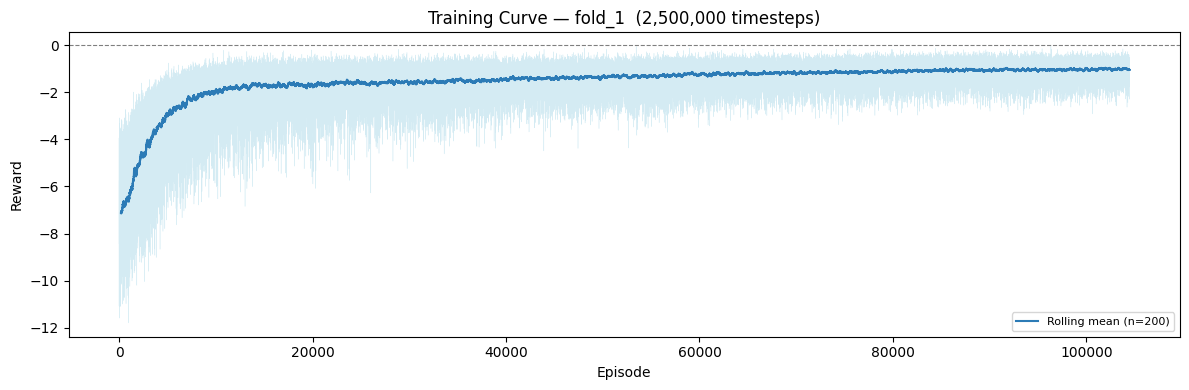

  ✅ fold_1 complete. Best model loaded.

  TRAINING — fold_2  (train → 2020-12-31, val → 2021-12-31)
  Train days: 654  |  Timesteps: 3,978,102
  Parameters : 556,655
  n_envs     : 4  (DummyVecEnv)
  obs_dim    : 544


C:\Users\youssef\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\stable_baselines3\common\callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_monitor.VecMonitor object at 0x000001EBE4C63610> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x000001EBE4C5FBB0>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


Eval num_timesteps=20000, episode_reward=-3.34 +/- 0.00
Episode length: 24.00 +/- 0.00
New best mean reward!


Eval num_timesteps=40000, episode_reward=-2.62 +/- 0.00
Episode length: 24.00 +/- 0.00
New best mean reward!


Eval num_timesteps=60000, episode_reward=-2.46 +/- 0.00
Episode length: 24.00 +/- 0.00
New best mean reward!


...

Eval num_timesteps=1820000, episode_reward=1.05 +/- 0.00
Episode length: 24.00 +/- 0.00


Eval num_timesteps=1840000, episode_reward=1.05 +/- 0.00
Episode length: 24.00 +/- 0.00


Eval num_timesteps=1860000, episode_reward=1.08 +/- 0.00
Episode length: 24.00 +/- 0.00


Eval num_timesteps=1880000, episode_reward=1.03 +/- 0.00
Episode length: 24.00 +/- 0.00


Eval num_timesteps=1900000, episode_reward=1.10 +/- 0.00
Episode length: 24.00 +/- 0.00
Stopping training because there was no new best model in the last 51 evaluations


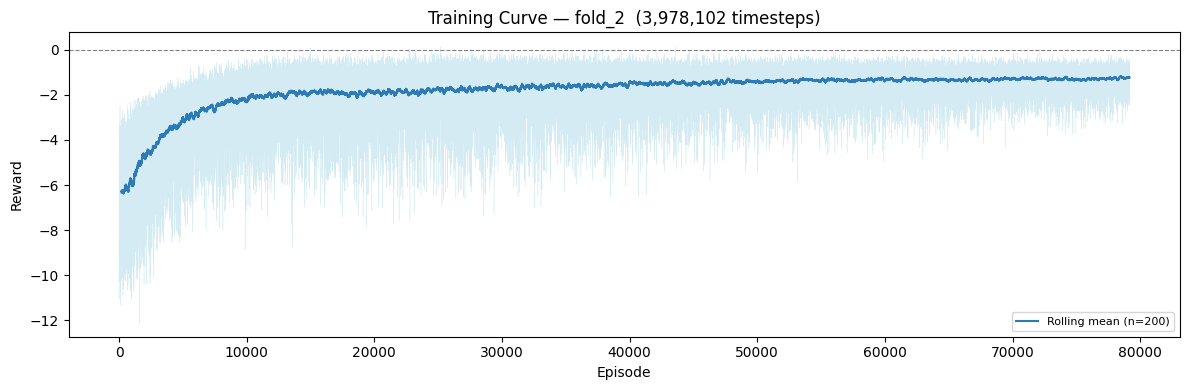

  ✅ fold_2 complete. Best model loaded.

  TRAINING — fold_3  (train → 2021-12-31, val → 2022-12-31)
  Train days: 898  |  Timesteps: 5,462,287
  Parameters : 556,655
  n_envs     : 4  (DummyVecEnv)
  obs_dim    : 544


C:\Users\youssef\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\stable_baselines3\common\callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_monitor.VecMonitor object at 0x000001EBE5958F50> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x000001EBE5F68F30>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


Eval num_timesteps=20000, episode_reward=-1.11 +/- 0.00
Episode length: 24.00 +/- 0.00
New best mean reward!


Eval num_timesteps=40000, episode_reward=-0.89 +/- 0.00
Episode length: 24.00 +/- 0.00
New best mean reward!


Eval num_timesteps=60000, episode_reward=-0.68 +/- 0.00
Episode length: 24.00 +/- 0.00
New best mean reward!


...

Eval num_timesteps=1600000, episode_reward=0.66 +/- 0.00
Episode length: 24.00 +/- 0.00


Eval num_timesteps=1620000, episode_reward=0.41 +/- 0.00
Episode length: 24.00 +/- 0.00


Eval num_timesteps=1640000, episode_reward=0.57 +/- 0.00
Episode length: 24.00 +/- 0.00


Eval num_timesteps=1660000, episode_reward=0.82 +/- 0.00
Episode length: 24.00 +/- 0.00


Eval num_timesteps=1680000, episode_reward=0.72 +/- 0.00
Episode length: 24.00 +/- 0.00
Stopping training because there was no new best model in the last 51 evaluations


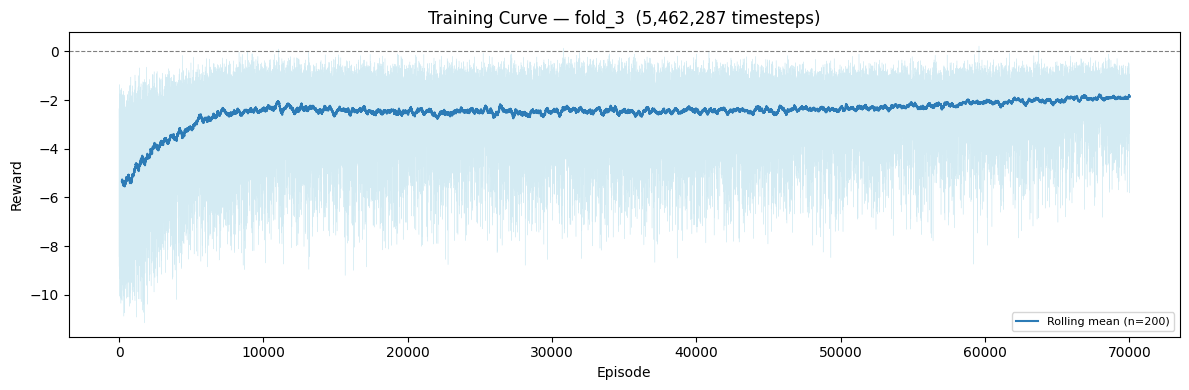

  ✅ fold_3 complete. Best model loaded.

  TRAINING — fold_4  (train → 2022-12-31, val → 2023-12-31)
  Train days: 1142  |  Timesteps: 6,946,472
  Parameters : 556,655
  n_envs     : 4  (DummyVecEnv)
  obs_dim    : 544


C:\Users\youssef\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\stable_baselines3\common\callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_monitor.VecMonitor object at 0x000001EBF26DEFD0> != <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x000001EBE5FE9310>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


Eval num_timesteps=20000, episode_reward=-0.17 +/- 0.00
Episode length: 24.00 +/- 0.00
New best mean reward!


Eval num_timesteps=40000, episode_reward=-0.03 +/- 0.00
Episode length: 24.00 +/- 0.00
New best mean reward!


Eval num_timesteps=60000, episode_reward=0.06 +/- 0.00
Episode length: 24.00 +/- 0.00
New best mean reward!


...

Eval num_timesteps=1700000, episode_reward=1.01 +/- 0.00
Episode length: 24.00 +/- 0.00


Eval num_timesteps=1720000, episode_reward=0.92 +/- 0.00
Episode length: 24.00 +/- 0.00


Eval num_timesteps=1740000, episode_reward=0.92 +/- 0.00
Episode length: 24.00 +/- 0.00


Eval num_timesteps=1760000, episode_reward=0.86 +/- 0.00
Episode length: 24.00 +/- 0.00


Eval num_timesteps=1780000, episode_reward=0.97 +/- 0.00
Episode length: 24.00 +/- 0.00
Stopping training because there was no new best model in the last 51 evaluations


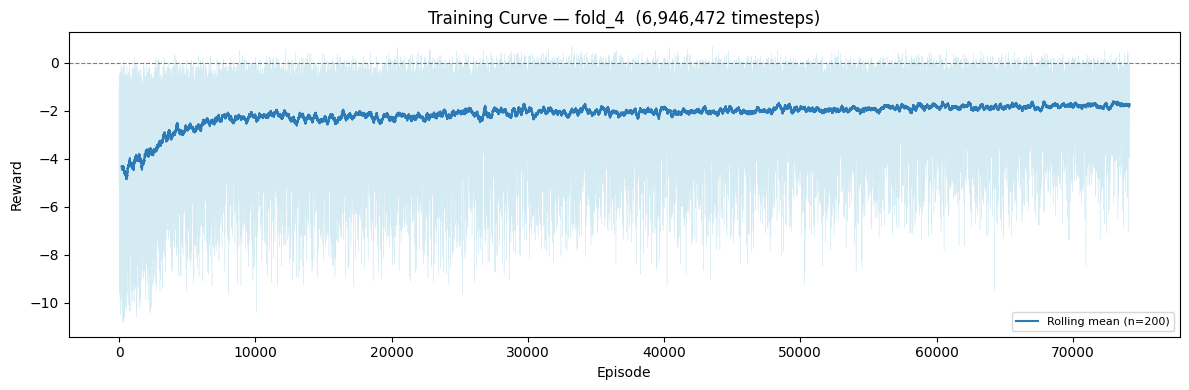

  ✅ fold_4 complete. Best model loaded.


In [24]:
fold_models     = {}
fold_plots_dirs = {}

for fold in WALK_FORWARD_FOLDS:
    fold_name  = fold["name"]
    split      = fold_split_indices[fold_name]

    # ── Proportional timesteps ────────────────────────────────────────────────
    n_train_days   = len(split["train"])
    fold_timesteps = int(BASE_TIMESTEPS * n_train_days / _fold1_train_days)

    # ── Directories ──────────────────────────────────────────────────────────
    fold_models_dir  = BASE_DIR / "models"  / RISK_PROFILE / VERSION / fold_name
    fold_logs_dir    = BASE_DIR / "logs"    / RISK_PROFILE / VERSION / fold_name
    fold_plots_dir   = BASE_DIR / "outputs" / RISK_PROFILE / VERSION / fold_name / "plots"
    fold_results_dir = BASE_DIR / "outputs" / RISK_PROFILE / VERSION / fold_name / "results"
    for d in [fold_models_dir, fold_logs_dir, fold_plots_dir, fold_results_dir]:
        d.mkdir(parents=True, exist_ok=True)

    fold_plots_dirs[fold_name] = fold_plots_dir
    model_save_path = fold_models_dir / "best_model"

    print(f"\n{'='*62}")
    print(f"  TRAINING — {fold_name}  "
          f"(train → {fold['train_end']}, val → {fold['val_end']})")
    print(f"  Train days: {n_train_days}  |  Timesteps: {fold_timesteps:,}")
    print(f"{'='*62}")

    # ── VecEnv factory ────────────────────────────────────────────────────────
    def make_env_fn(split_indices=split):
        def _init():
            return PortfolioEnv(
                feature_tensor   = feature_tensor,
                returns_tensor   = returns_tensor,
                mask_tensor      = mask_tensor,
                market_signal    = market_signal,
                universe_indices = universe_indices,
                split_indices    = split_indices,
                risk_profile     = RISK_PROFILE,
                feature_names    = feature_names,
                mode             = "train",
                episode_length   = EPISODE_LENGTH,
                rebalance_days   = REBALANCE_DAYS,
                silent           = True,
            )
        return _init

    train_vec = DummyVecEnv([make_env_fn(split) for _ in range(N_ENVS)])
    train_vec = VecMonitor(train_vec,
                           filename=str(fold_logs_dir / "monitor_train"))

    # ── Validation env ────────────────────────────────────────────────────────
    val_env_single = PortfolioEnv(
        feature_tensor   = feature_tensor,
        returns_tensor   = returns_tensor,
        mask_tensor      = mask_tensor,
        market_signal    = market_signal,
        universe_indices = universe_indices,
        split_indices    = split,
        risk_profile     = RISK_PROFILE,
        feature_names    = feature_names,
        mode             = "val",
        episode_length   = EPISODE_LENGTH,
        rebalance_days   = REBALANCE_DAYS,
        silent           = True,
    )
    val_env_monitored = Monitor(val_env_single,
                                filename=str(fold_logs_dir / "monitor_val"))

    # ── PPO model ─────────────────────────────────────────────────────────────
    model = PPO(
        env             = train_vec,
        seed            = 42,
        tensorboard_log = str(fold_logs_dir / "tensorboard"),
        **PPO_PARAMS,
    )

    total_params = sum(p.numel() for p in model.policy.parameters())
    print(f"  Parameters : {total_params:,}")
    print(f"  n_envs     : {N_ENVS}  (DummyVecEnv)")
    print(f"  obs_dim    : {model.observation_space.shape[0]}")

    # ── Callbacks ─────────────────────────────────────────────────────────────
    stop_callback = StopTrainingOnNoModelImprovement(
        max_no_improvement_evals = 50,
        min_evals                = 60,
        verbose                  = 1,
    )
    eval_callback = EvalWithStopCallback(
        stop_callback        = stop_callback,
        eval_env             = val_env_monitored,
        best_model_save_path = str(model_save_path),
        log_path             = str(fold_logs_dir / "eval"),
        eval_freq            = max(20_000 // N_ENVS, 1),
        n_eval_episodes      = 1,
        deterministic        = True,
        render               = False,
        verbose              = 1,
    )
    reward_logger = RewardLoggerCallback(
        log_path = str(fold_logs_dir / "rl_training_history.csv"),
        verbose  = 1,
    )
    metrics_callback = TrainingMetricsCallback(
        print_every_n_updates = 20,
        verbose               = 1,
    )

    # ── Train ─────────────────────────────────────────────────────────────────
    model.learn(
        total_timesteps     = fold_timesteps,
        callback            = [eval_callback, reward_logger, metrics_callback],
        progress_bar        = False,
        reset_num_timesteps = True,
    )

    # ── Training curve ────────────────────────────────────────────────────────
    history_path = fold_logs_dir / "rl_training_history.csv"
    if history_path.exists():
        history_df = pd.read_csv(str(history_path))
        window     = 200
        history_df["rolling_mean"] = history_df["episode_reward"].rolling(window).mean()

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(history_df["episode"], history_df["episode_reward"],
                color="#abd9e9", linewidth=0.3, alpha=0.5)
        ax.plot(history_df["episode"], history_df["rolling_mean"],
                color="#2c7bb6", linewidth=1.5, label=f"Rolling mean (n={window})")
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
        ax.set_xlabel("Episode")
        ax.set_ylabel("Reward")
        ax.set_title(f"Training Curve — {fold_name}  ({fold_timesteps:,} timesteps)")
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(fold_plots_dir / "training_curve.png", dpi=120, bbox_inches="tight")
        plt.show()

        sys.__stdout__.write(
            f"  Episodes: {len(history_df):,} | "
            f"First 500 mean: {history_df['episode_reward'][:500].mean():.3f} | "
            f"Last 500 mean: {history_df['episode_reward'][-500:].mean():.3f}\n"
        )

    # ── Load best checkpoint ──────────────────────────────────────────────────
    best_model = PPO.load(
        str(model_save_path / "best_model"),
        env=val_env_monitored,
    )
    fold_models[fold_name] = best_model
    print(f"  ✅ {fold_name} complete. Best model loaded.")

## 12. Multi-Episode Evaluation Across All Folds

In [25]:
_template_env = PortfolioEnv(
    feature_tensor   = feature_tensor,
    returns_tensor   = returns_tensor,
    mask_tensor      = mask_tensor,
    market_signal    = market_signal,
    universe_indices = universe_indices,
    split_indices    = fold_split_indices["fold_1"],
    risk_profile     = RISK_PROFILE,
    feature_names    = feature_names,
    mode             = "test",
    episode_length   = EPISODE_LENGTH,
    rebalance_days   = REBALANCE_DAYS,
    silent           = True,
)


  EVALUATION — fold_1  (test → 2021-12-31)

[VAL]


  RL  : 1200 returns from 50 episodes
  EQW : 1200 returns

-- RL Agent — val [fold_1] --
  N returns         : 1200
  Annualized return :    66.38%
  Risk-free (CONIA) :    21.00%
  Annualized vol    :    32.64%
  Sharpe ratio      :    1.390
  Sortino ratio     :    3.308
  Max drawdown      :    35.67%
  Calmar ratio      :    1.861
  CVaR (95%, per-period) :  -11.06%

-- Equal Weight — val [fold_1] --
  N returns         : 1200
  Annualized return :    -1.03%
  Risk-free (CONIA) :    21.00%
  Annualized vol    :    23.86%
  Sharpe ratio      :   -0.923
  Sortino ratio     :   -1.331
  Max drawdown      :    94.58%
  Calmar ratio      :   -0.011
  CVaR (95%, per-period) :  -16.43%



  Bootstrap CIs (95%, block=3, n=2000) — RL val [fold_1]
    Ann. return          : [+59.58%, +73.45%]
    Sharpe               : [+1.176,  +1.612]
    CVaR 95% (per-period): [-11.92%, -10.05%]



  Bootstrap CIs (95%, block=3, n=2000) — EQW val [fold_1]
    Ann. return          : [-5.22%, +3.44%]
    Sharpe               : [-1.100,  -0.733]
    CVaR 95% (per-period): [-17.60%, -14.96%]

  Statistical tests (val fold_1):
    H0: RL excess return == equal-weight excess return
    t-test  : t=+33.504  p=0.0000  ✓ significant at 5%  [outperforms EQW]
    Wilcoxon: W=50779.0  p=0.0000  ✓ significant at 5%

[TEST]


  RL  : 1200 returns from 50 episodes
  EQW : 1200 returns

-- RL Agent — test [fold_1] --
  N returns         : 1200
  Annualized return :    47.19%
  Risk-free (CONIA) :    21.00%
  Annualized vol    :    31.96%
  Sharpe ratio      :    0.819
  Sortino ratio     :    1.837
  Max drawdown      :    35.67%
  Calmar ratio      :    1.323
  CVaR (95%, per-period) :  -12.56%

-- Equal Weight — test [fold_1] --
  N returns         : 1200
  Annualized return :    19.72%
  Risk-free (CONIA) :    21.00%
  Annualized vol    :    25.83%
  Sharpe ratio      :   -0.050
  Sortino ratio     :   -0.090
  Max drawdown      :    36.88%
  Calmar ratio      :    0.535
  CVaR (95%, per-period) :  -12.98%



  Bootstrap CIs (95%, block=3, n=2000) — RL test [fold_1]
    Ann. return          : [+40.10%, +54.43%]
    Sharpe               : [+0.598,  +1.050]
    CVaR 95% (per-period): [-13.33%, -11.48%]



  Bootstrap CIs (95%, block=3, n=2000) — EQW test [fold_1]
    Ann. return          : [+14.29%, +24.97%]
    Sharpe               : [-0.261,  +0.159]
    CVaR 95% (per-period): [-14.12%, -11.80%]

  Statistical tests (test fold_1):
    H0: RL excess return == equal-weight excess return
    t-test  : t=+14.050  p=0.0000  ✓ significant at 5%  [outperforms EQW]
    Wilcoxon: W=221962.0  p=0.0000  ✓ significant at 5%


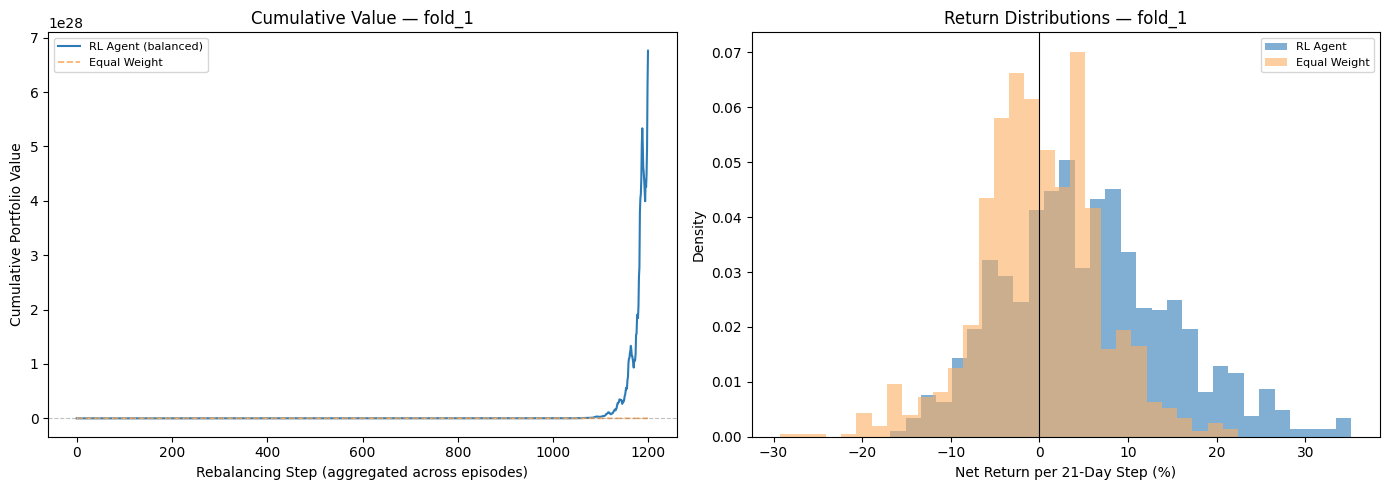

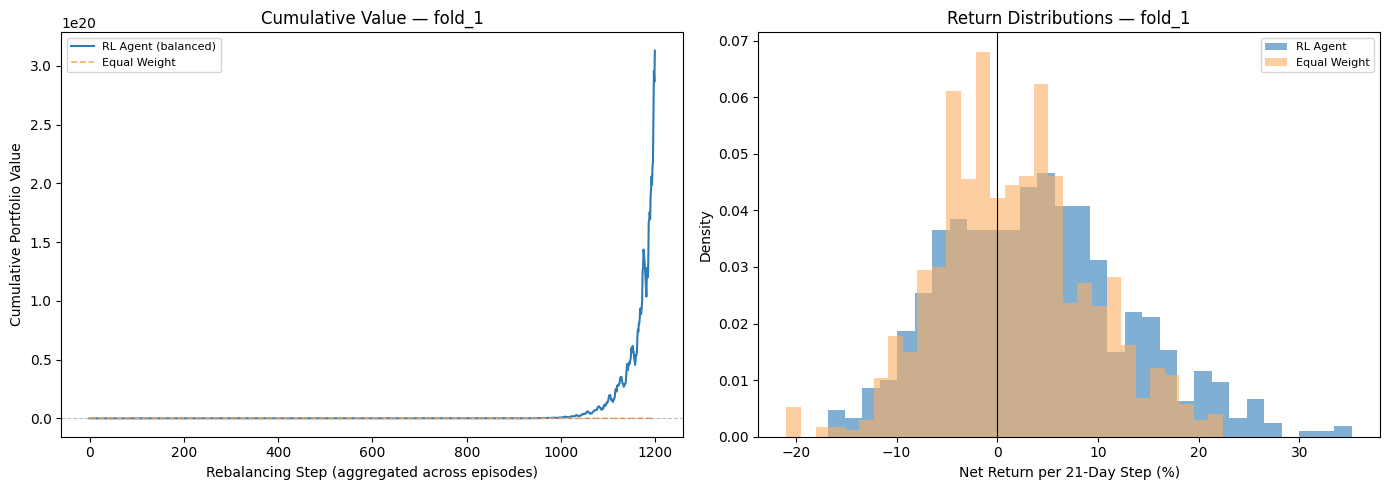


  EVALUATION — fold_2  (test → 2022-12-31)

[VAL]


  RL  : 1200 returns from 50 episodes
  EQW : 1200 returns

-- RL Agent — val [fold_2] --
  N returns         : 1200
  Annualized return :   103.97%
  Risk-free (CONIA) :    21.00%
  Annualized vol    :    28.38%
  Sharpe ratio      :    2.924
  Sortino ratio     :    7.399
  Max drawdown      :    16.39%
  Calmar ratio      :    6.344
  CVaR (95%, per-period) :   -7.08%

-- Equal Weight — val [fold_2] --
  N returns         : 1200
  Annualized return :    19.72%
  Risk-free (CONIA) :    21.00%
  Annualized vol    :    25.83%
  Sharpe ratio      :   -0.050
  Sortino ratio     :   -0.090
  Max drawdown      :    36.88%
  Calmar ratio      :    0.535
  CVaR (95%, per-period) :  -12.98%



  Bootstrap CIs (95%, block=3, n=2000) — RL val [fold_2]
    Ann. return          : [+98.64%, +109.36%]
    Sharpe               : [+2.714,  +3.144]
    CVaR 95% (per-period): [-7.99%, -6.14%]



  Bootstrap CIs (95%, block=3, n=2000) — EQW val [fold_2]
    Ann. return          : [+14.24%, +25.30%]
    Sharpe               : [-0.263,  +0.166]
    CVaR 95% (per-period): [-14.19%, -11.76%]

  Statistical tests (val fold_2):
    H0: RL excess return == equal-weight excess return
    t-test  : t=+35.437  p=0.0000  ✓ significant at 5%  [outperforms EQW]
    Wilcoxon: W=50920.0  p=0.0000  ✓ significant at 5%

[TEST]


  RL  : 1200 returns from 50 episodes
  EQW : 1200 returns

-- RL Agent — test [fold_2] --
  N returns         : 1200
  Annualized return :    61.21%
  Risk-free (CONIA) :    21.00%
  Annualized vol    :    33.27%
  Sharpe ratio      :    1.208
  Sortino ratio     :    1.972
  Max drawdown      :    36.50%
  Calmar ratio      :    1.677
  CVaR (95%, per-period) :  -16.84%

-- Equal Weight — test [fold_2] --
  N returns         : 1200
  Annualized return :    44.73%
  Risk-free (CONIA) :    21.00%
  Annualized vol    :    27.12%
  Sharpe ratio      :    0.875
  Sortino ratio     :    1.382
  Max drawdown      :    36.97%
  Calmar ratio      :    1.210
  CVaR (95%, per-period) :  -13.83%



  Bootstrap CIs (95%, block=3, n=2000) — RL test [fold_2]
    Ann. return          : [+54.91%, +67.74%]
    Sharpe               : [+1.007,  +1.419]
    CVaR 95% (per-period): [-18.52%, -14.75%]



  Bootstrap CIs (95%, block=3, n=2000) — EQW test [fold_2]
    Ann. return          : [+39.33%, +49.79%]
    Sharpe               : [+0.674,  +1.091]
    CVaR 95% (per-period): [-14.84%, -12.76%]

  Statistical tests (test fold_2):
    H0: RL excess return == equal-weight excess return
    t-test  : t=+8.888  p=0.0000  ✓ significant at 5%  [outperforms EQW]
    Wilcoxon: W=265232.0  p=0.0000  ✓ significant at 5%


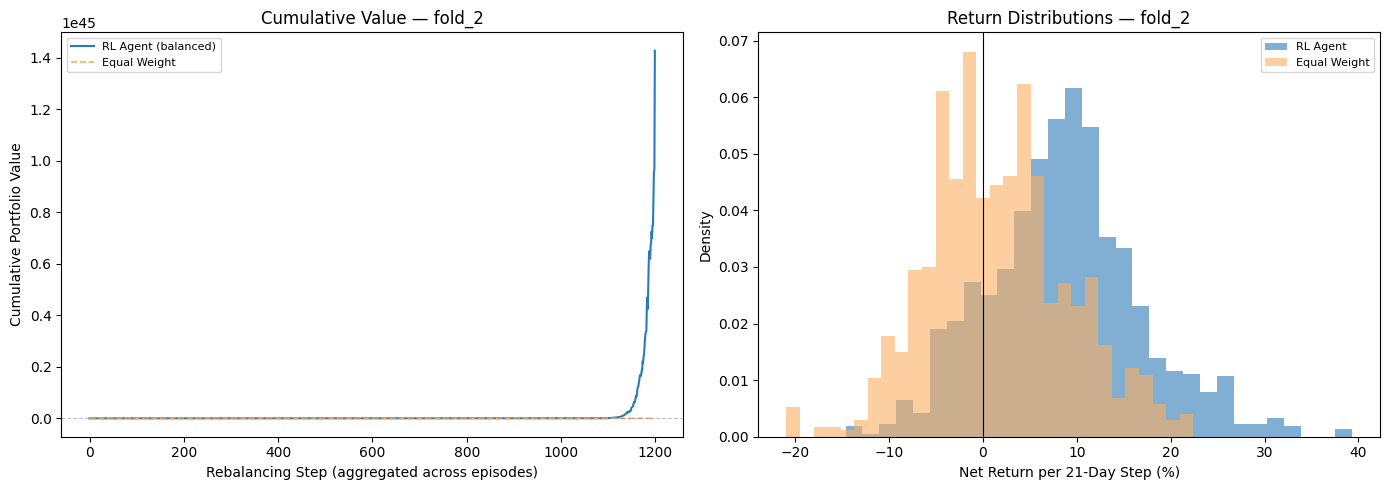

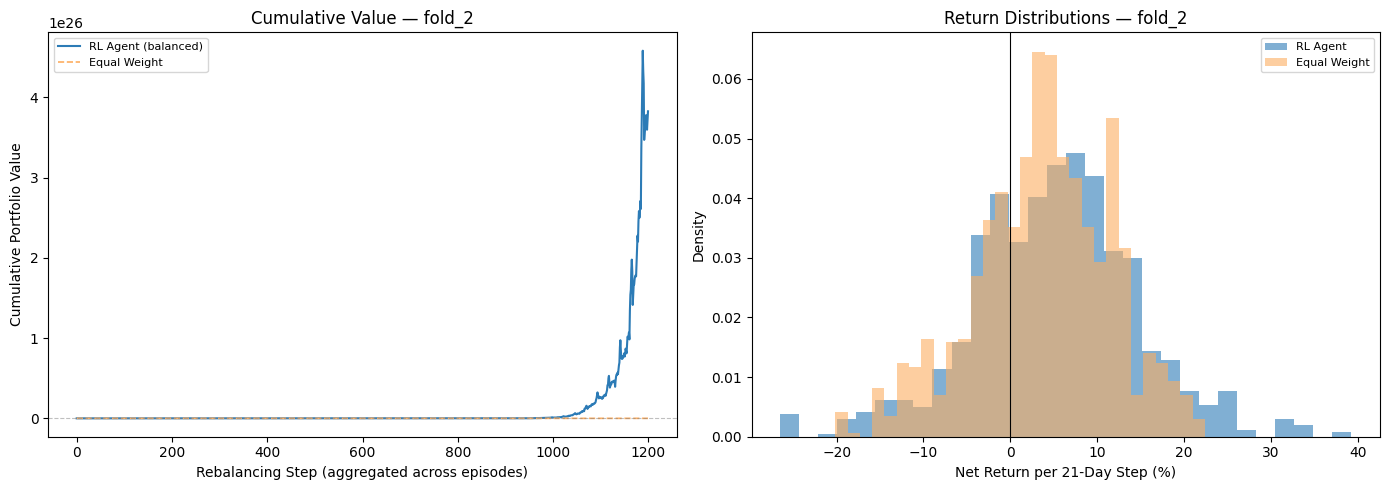


  EVALUATION — fold_3  (test → 2023-12-31)

[VAL]


  RL  : 1200 returns from 50 episodes
  EQW : 1200 returns

-- RL Agent — val [fold_3] --
  N returns         : 1200
  Annualized return :    81.98%
  Risk-free (CONIA) :    21.00%
  Annualized vol    :    33.73%
  Sharpe ratio      :    1.808
  Sortino ratio     :    3.438
  Max drawdown      :    32.49%
  Calmar ratio      :    2.523
  CVaR (95%, per-period) :  -13.24%

-- Equal Weight — val [fold_3] --
  N returns         : 1200
  Annualized return :    44.73%
  Risk-free (CONIA) :    21.00%
  Annualized vol    :    27.12%
  Sharpe ratio      :    0.875
  Sortino ratio     :    1.382
  Max drawdown      :    36.97%
  Calmar ratio      :    1.210
  CVaR (95%, per-period) :  -13.83%



  Bootstrap CIs (95%, block=3, n=2000) — RL val [fold_3]
    Ann. return          : [+75.46%, +88.30%]
    Sharpe               : [+1.584,  +2.028]
    CVaR 95% (per-period): [-14.93%, -11.45%]



  Bootstrap CIs (95%, block=3, n=2000) — EQW val [fold_3]
    Ann. return          : [+39.55%, +49.96%]
    Sharpe               : [+0.659,  +1.077]
    CVaR 95% (per-period): [-14.83%, -12.79%]

  Statistical tests (val fold_3):
    H0: RL excess return == equal-weight excess return
    t-test  : t=+17.978  p=0.0000  ✓ significant at 5%  [outperforms EQW]
    Wilcoxon: W=165048.0  p=0.0000  ✓ significant at 5%

[TEST]


  RL  : 1200 returns from 50 episodes
  EQW : 1200 returns

-- RL Agent — test [fold_3] --
  N returns         : 1200
  Annualized return :    36.94%
  Risk-free (CONIA) :    21.00%
  Annualized vol    :    27.56%
  Sharpe ratio      :    0.578
  Sortino ratio     :    0.988
  Max drawdown      :    32.49%
  Calmar ratio      :    1.137
  CVaR (95%, per-period) :  -13.56%

-- Equal Weight — test [fold_3] --
  N returns         : 1200
  Annualized return :    34.06%
  Risk-free (CONIA) :    21.00%
  Annualized vol    :    21.30%
  Sharpe ratio      :    0.613
  Sortino ratio     :    0.802
  Max drawdown      :    23.85%
  Calmar ratio      :    1.428
  CVaR (95%, per-period) :  -12.90%



  Bootstrap CIs (95%, block=3, n=2000) — RL test [fold_3]
    Ann. return          : [+31.17%, +42.77%]
    Sharpe               : [+0.364,  +0.778]
    CVaR 95% (per-period): [-15.38%, -11.69%]



  Bootstrap CIs (95%, block=3, n=2000) — EQW test [fold_3]
    Ann. return          : [+29.80%, +38.51%]
    Sharpe               : [+0.406,  +0.834]
    CVaR 95% (per-period): [-13.70%, -11.69%]

  Statistical tests (test fold_3):
    H0: RL excess return == equal-weight excess return
    t-test  : t=+1.725  p=0.0848  ✗ not significant at 5%  [outperforms EQW]
    Wilcoxon: W=356608.0  p=0.7585  ✗ not significant at 5%


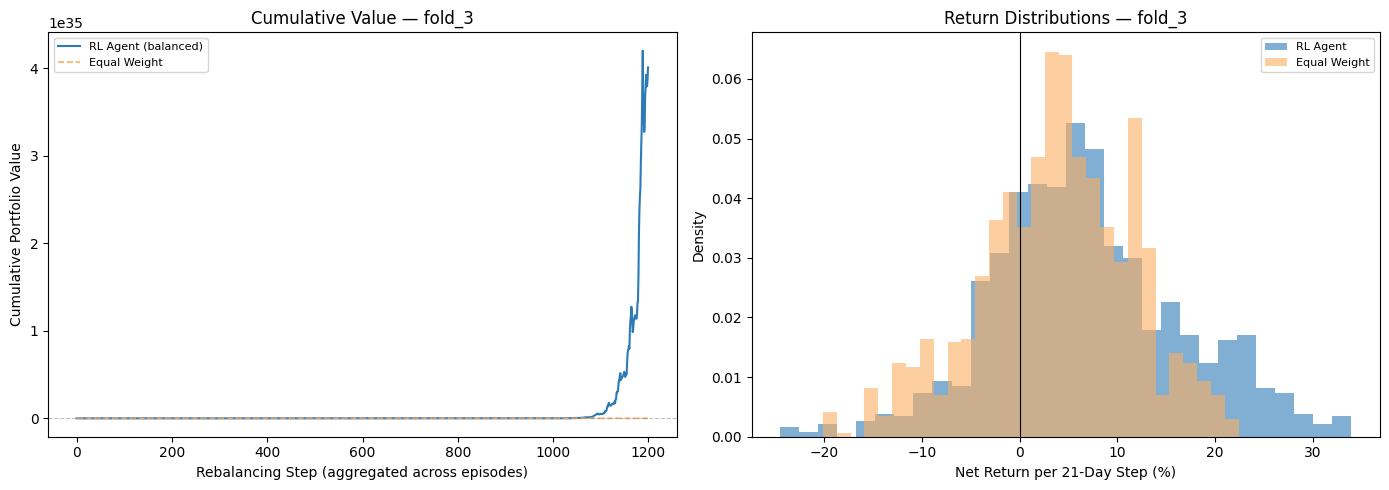

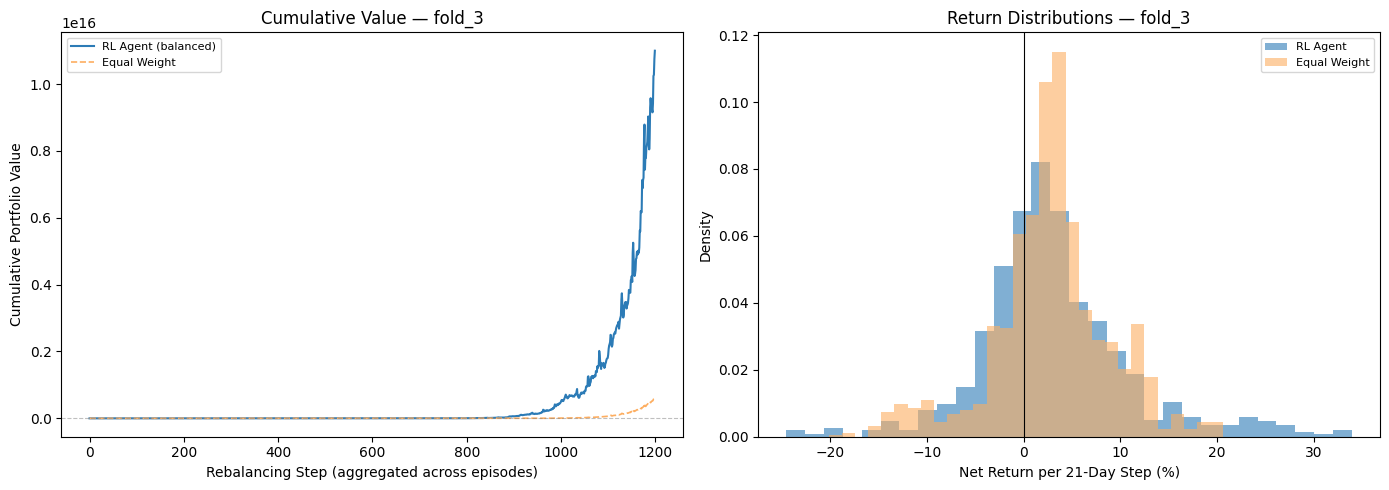


  EVALUATION — fold_4  (test → 2025-12-31)

[VAL]


  RL  : 1200 returns from 50 episodes
  EQW : 1200 returns

-- RL Agent — val [fold_4] --
  N returns         : 1200
  Annualized return :    85.87%
  Risk-free (CONIA) :    21.00%
  Annualized vol    :    33.32%
  Sharpe ratio      :    1.947
  Sortino ratio     :    5.819
  Max drawdown      :    14.98%
  Calmar ratio      :    5.734
  CVaR (95%, per-period) :   -7.78%

-- Equal Weight — val [fold_4] --
  N returns         : 1200
  Annualized return :    34.06%
  Risk-free (CONIA) :    21.00%
  Annualized vol    :    21.30%
  Sharpe ratio      :    0.613
  Sortino ratio     :    0.802
  Max drawdown      :    23.85%
  Calmar ratio      :    1.428
  CVaR (95%, per-period) :  -12.90%



  Bootstrap CIs (95%, block=3, n=2000) — RL val [fold_4]
    Ann. return          : [+78.24%, +92.95%]
    Sharpe               : [+1.770,  +2.113]
    CVaR 95% (per-period): [-8.89%, -6.70%]



  Bootstrap CIs (95%, block=3, n=2000) — EQW val [fold_4]
    Ann. return          : [+29.80%, +38.30%]
    Sharpe               : [+0.404,  +0.829]
    CVaR 95% (per-period): [-13.68%, -11.61%]

  Statistical tests (val fold_4):
    H0: RL excess return == equal-weight excess return
    t-test  : t=+20.178  p=0.0000  ✓ significant at 5%  [outperforms EQW]
    Wilcoxon: W=139597.0  p=0.0000  ✓ significant at 5%

[TEST]


  RL  : 1200 returns from 50 episodes
  EQW : 1200 returns

-- RL Agent — test [fold_4] --
  N returns         : 1200
  Annualized return :    44.81%
  Risk-free (CONIA) :    21.00%
  Annualized vol    :    22.50%
  Sharpe ratio      :    1.058
  Sortino ratio     :    2.339
  Max drawdown      :    14.83%
  Calmar ratio      :    3.021
  CVaR (95%, per-period) :   -7.80%

-- Equal Weight — test [fold_4] --
  N returns         : 1200
  Annualized return :    22.65%
  Risk-free (CONIA) :    21.00%
  Annualized vol    :    17.42%
  Sharpe ratio      :    0.095
  Sortino ratio     :    0.102
  Max drawdown      :    24.34%
  Calmar ratio      :    0.931
  CVaR (95%, per-period) :  -12.87%



  Bootstrap CIs (95%, block=3, n=2000) — RL test [fold_4]
    Ann. return          : [+40.43%, +49.20%]
    Sharpe               : [+0.904,  +1.219]
    CVaR 95% (per-period): [-8.83%, -6.75%]



  Bootstrap CIs (95%, block=3, n=2000) — EQW test [fold_4]
    Ann. return          : [+19.26%, +25.90%]
    Sharpe               : [-0.101,  +0.310]
    CVaR 95% (per-period): [-13.59%, -11.62%]

  Statistical tests (test fold_4):
    H0: RL excess return == equal-weight excess return
    t-test  : t=+11.128  p=0.0000  ✓ significant at 5%  [outperforms EQW]
    Wilcoxon: W=254154.0  p=0.0000  ✓ significant at 5%


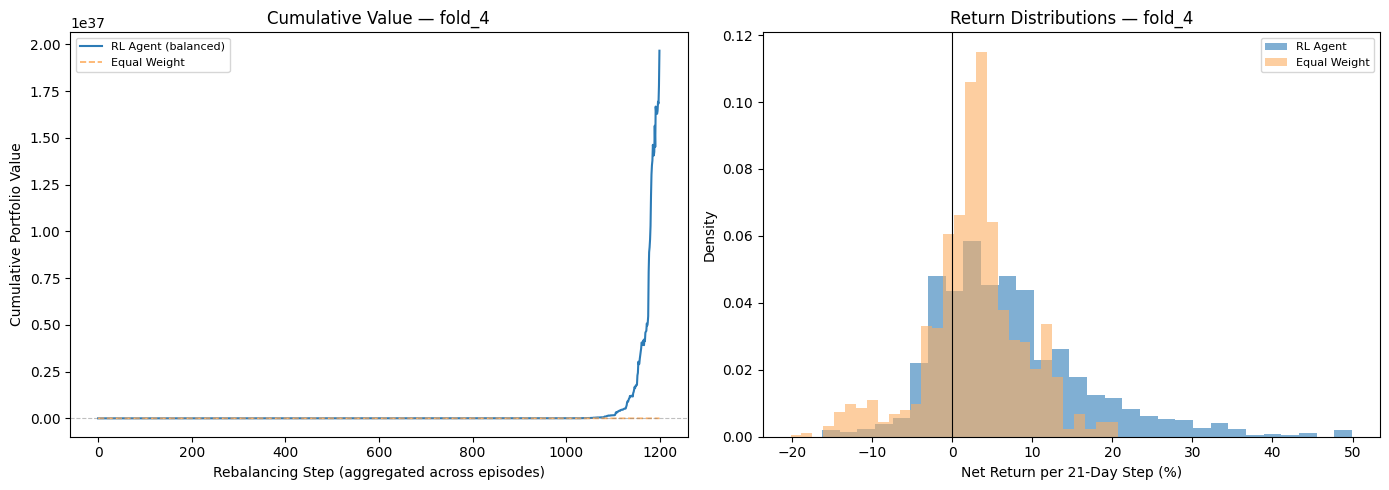

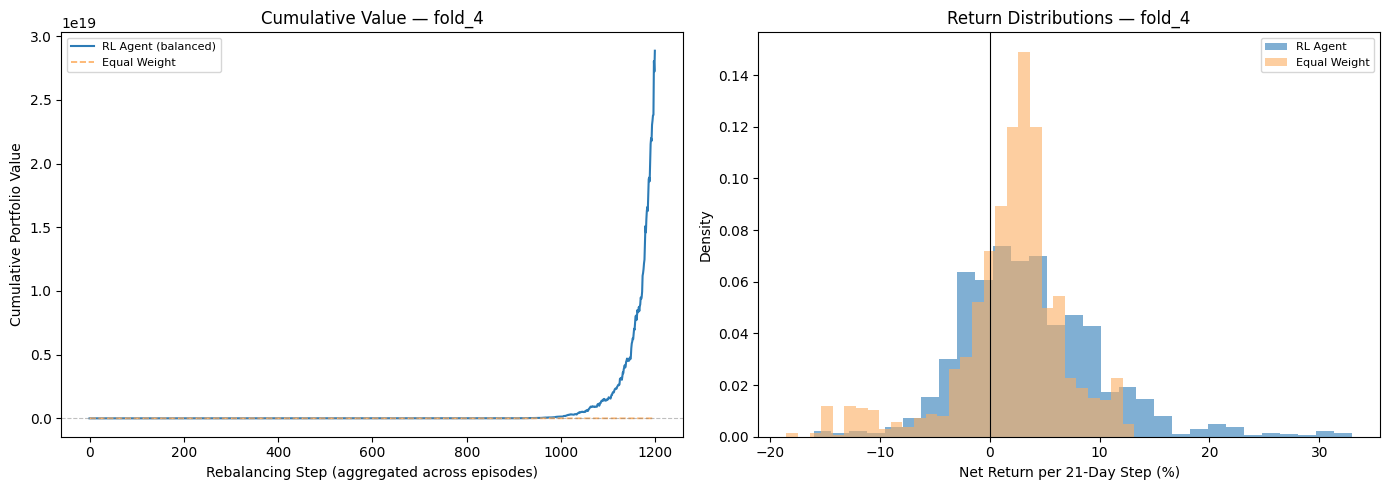


✅ All fold evaluations complete.


In [26]:
all_fold_results = {}

for fold in WALK_FORWARD_FOLDS:
    fold_name = fold["name"]
    split     = fold_split_indices[fold_name]
    model     = fold_models[fold_name]
    plots_dir = fold_plots_dirs[fold_name]

    print(f"\n{'='*60}")
    print(f"  EVALUATION — {fold_name}  (test → {fold['test_end']})")
    print(f"{'='*60}")

    # ── Val ───────────────────────────────────────────────────────────────────
    print(f"\n[VAL]")
    rl_val_returns, rl_val_episodes = multi_episode_evaluate(
        model, _template_env, split, "val", EPISODE_LENGTH
    )
    eq_val_returns = multi_episode_equal_weight(
        _template_env, split, "val", EPISODE_LENGTH
    )
    print(f"  RL  : {len(rl_val_returns)} returns from {len(rl_val_episodes)} episodes")
    print(f"  EQW : {len(eq_val_returns)} returns")

    rl_val_metrics = compute_metrics(rl_val_returns,  f"RL Agent — val [{fold_name}]")
    eq_val_metrics = compute_metrics(eq_val_returns,   f"Equal Weight — val [{fold_name}]")
    rl_val_ci      = compute_bootstrap_cis(rl_val_returns,  f"RL val [{fold_name}]")
    eq_val_ci      = compute_bootstrap_cis(eq_val_returns,   f"EQW val [{fold_name}]")
    val_sig        = significance_test(
        rl_val_returns[:min(len(rl_val_returns), len(eq_val_returns))],
        eq_val_returns[:min(len(rl_val_returns), len(eq_val_returns))],
        label=f"val {fold_name}"
    )

    # ── Test ──────────────────────────────────────────────────────────────────
    print(f"\n[TEST]")
    rl_test_returns, rl_test_episodes = multi_episode_evaluate(
        model, _template_env, split, "test", EPISODE_LENGTH
    )
    eq_test_returns = multi_episode_equal_weight(
        _template_env, split, "test", EPISODE_LENGTH
    )
    print(f"  RL  : {len(rl_test_returns)} returns from {len(rl_test_episodes)} episodes")
    print(f"  EQW : {len(eq_test_returns)} returns")

    rl_test_metrics = compute_metrics(rl_test_returns,  f"RL Agent — test [{fold_name}]")
    eq_test_metrics = compute_metrics(eq_test_returns,   f"Equal Weight — test [{fold_name}]")
    rl_test_ci      = compute_bootstrap_cis(rl_test_returns,  f"RL test [{fold_name}]")
    eq_test_ci      = compute_bootstrap_cis(eq_test_returns,   f"EQW test [{fold_name}]")
    test_sig        = significance_test(
        rl_test_returns[:min(len(rl_test_returns), len(eq_test_returns))],
        eq_test_returns[:min(len(rl_test_returns), len(eq_test_returns))],
        label=f"test {fold_name}"
    )

    plot_fold_results(rl_val_returns,  eq_val_returns,  fold_name, "val",  plots_dir)
    plot_fold_results(rl_test_returns, eq_test_returns, fold_name, "test", plots_dir)

    fold_result = {
        "fold":              fold_name,
        "train_end":         fold["train_end"],
        "val_end":           fold["val_end"],
        "test_end":          fold["test_end"],
        "rl_val":            rl_val_metrics,
        "eq_val":            eq_val_metrics,
        "rl_val_ci":         rl_val_ci,
        "rl_test":           rl_test_metrics,
        "eq_test":           eq_test_metrics,
        "rl_test_ci":        rl_test_ci,
        "val_significance":  val_sig,
        "test_significance": test_sig,
    }
    all_fold_results[fold_name] = fold_result

    results_dir = BASE_DIR / "outputs" / RISK_PROFILE / VERSION / fold_name / "results"
    json.dump(fold_result, open(results_dir / "metrics.json", "w"),
              indent=2, default=str)

print(f"\n✅ All fold evaluations complete.")

## 13. Aggregate Results Across Folds

In [27]:
print(f"\n{'='*65}")
print(f"  CROSS-FOLD AGGREGATE RESULTS  ({len(WALK_FORWARD_FOLDS)} folds)")
print(f"{'='*65}")

metrics_keys = ["ann_return", "ann_vol", "sharpe", "sortino", "max_dd", "calmar", "cvar_95"]

rl_test_rows = []
eq_test_rows = []

for fold_name, result in all_fold_results.items():
    rl_row = {"fold": fold_name, "test_end": result["test_end"]}
    eq_row = {"fold": fold_name, "test_end": result["test_end"]}
    for k in metrics_keys:
        rl_row[k] = result["rl_test"].get(k, np.nan)
        eq_row[k] = result["eq_test"].get(k, np.nan)
    rl_test_rows.append(rl_row)
    eq_test_rows.append(eq_row)

rl_df = pd.DataFrame(rl_test_rows).set_index("fold")
eq_df = pd.DataFrame(eq_test_rows).set_index("fold")

# Per-period columns (not annualized)
per_period_keys = {"cvar_95"}

print(f"\n── RL Agent — Test Metrics Per Fold ──")
display_cols = ["test_end", "ann_return", "sharpe", "sortino", "max_dd", "cvar_95"]
rl_display   = rl_df[display_cols].copy()
rl_display["ann_return"] = (rl_display["ann_return"] * 100).round(2)
rl_display["max_dd"]     = (rl_display["max_dd"]     * 100).round(2)
rl_display["cvar_95"]    = (rl_display["cvar_95"]    * 100).round(2)
rl_display["sharpe"]     = rl_display["sharpe"].round(3)
rl_display["sortino"]    = rl_display["sortino"].round(3)
print(rl_display.rename(columns={"cvar_95": "cvar_95(pp%)"}).to_string())

print(f"\n── Equal Weight — Test Metrics Per Fold ──")
eq_display   = eq_df[display_cols].copy()
eq_display["ann_return"] = (eq_display["ann_return"] * 100).round(2)
eq_display["max_dd"]     = (eq_display["max_dd"]     * 100).round(2)
eq_display["cvar_95"]    = (eq_display["cvar_95"]    * 100).round(2)
eq_display["sharpe"]     = eq_display["sharpe"].round(3)
eq_display["sortino"]    = eq_display["sortino"].round(3)
print(eq_display.rename(columns={"cvar_95": "cvar_95(pp%)"}).to_string())

print(f"\n── Cross-Fold Summary (TEST) ──")
print(f"  ann_return, ann_vol, max_dd: annualized (×12 or ×√12)")
print(f"  cvar_95: per-period fraction (NOT annualized) — avg worst 5% of 21d periods")
print(f"{'Metric':<22} {'RL Mean':>10} {'RL Std':>8} │ {'EQ Mean':>10} {'EQ Std':>8}")
print("─" * 67)
for k in metrics_keys:
    rl_vals = rl_df[k].dropna().values
    eq_vals = eq_df[k].dropna().values
    scale   = 100 if k in ["ann_return", "ann_vol", "max_dd", "cvar_95"] else 1
    unit    = "%" if scale == 100 else ""
    rl_mean = np.mean(rl_vals) * scale
    rl_std  = np.std(rl_vals)  * scale
    eq_mean = np.mean(eq_vals) * scale
    eq_std  = np.std(eq_vals)  * scale
    suffix  = " (pp)" if k == "cvar_95" else ""
    print(f"{k+suffix:<22} {rl_mean:>9.2f}{unit} {rl_std:>7.2f}{unit} │ "
          f"{eq_mean:>9.2f}{unit} {eq_std:>7.2f}{unit}")

# ── Significance summary ──────────────────────────────────────────────────────
print(f"\n── Fold-Level Significance Summary ──")
sig_rows = []
for fold_name, result in all_fold_results.items():
    sig = result["test_significance"]
    sig_rows.append({
        "fold":      fold_name,
        "direction": sig.get("direction", "?"),
        "t_pval":    sig.get("t_pval", np.nan),
        "w_pval":    sig.get("w_pval", np.nan),
        "sig_t":     "✓" if sig.get("t_pval", 1) < 0.05 else "✗",
        "sig_w":     "✓" if sig.get("w_pval", 1) < 0.05 else "✗",
    })
sig_df = pd.DataFrame(sig_rows).set_index("fold")
print(sig_df[["direction", "t_pval", "sig_t", "w_pval", "sig_w"]].round(4).to_string())

n_outperforms = ((sig_df["t_pval"] < 0.05) & (sig_df["direction"] == "outperforms")).sum()
n_underperforms = ((sig_df["t_pval"] < 0.05) & (sig_df["direction"] == "underperforms")).sum()
print(f"\nRL significantly outperforms EQW  : {n_outperforms}/{len(WALK_FORWARD_FOLDS)} folds")
print(f"RL significantly underperforms EQW: {n_underperforms}/{len(WALK_FORWARD_FOLDS)} folds")


  CROSS-FOLD AGGREGATE RESULTS  (4 folds)

── RL Agent — Test Metrics Per Fold ──
          test_end  ann_return  sharpe  sortino  max_dd  cvar_95(pp%)
fold                                                                 
fold_1  2021-12-31       47.19   0.819    1.837   35.67        -12.56
fold_2  2022-12-31       61.21   1.208    1.972   36.50        -16.84
fold_3  2023-12-31       36.94   0.578    0.988   32.49        -13.56
fold_4  2025-12-31       44.81   1.058    2.339   14.83         -7.80

── Equal Weight — Test Metrics Per Fold ──
          test_end  ann_return  sharpe  sortino  max_dd  cvar_95(pp%)
fold                                                                 
fold_1  2021-12-31       19.72  -0.050   -0.090   36.88        -12.98
fold_2  2022-12-31       44.73   0.875    1.382   36.97        -13.83
fold_3  2023-12-31       34.06   0.613    0.802   23.85        -12.90
fold_4  2025-12-31       22.65   0.095    0.102   24.34        -12.87

── Cross-Fold Summary (TEST) ──


## 14. Aggregate Plot

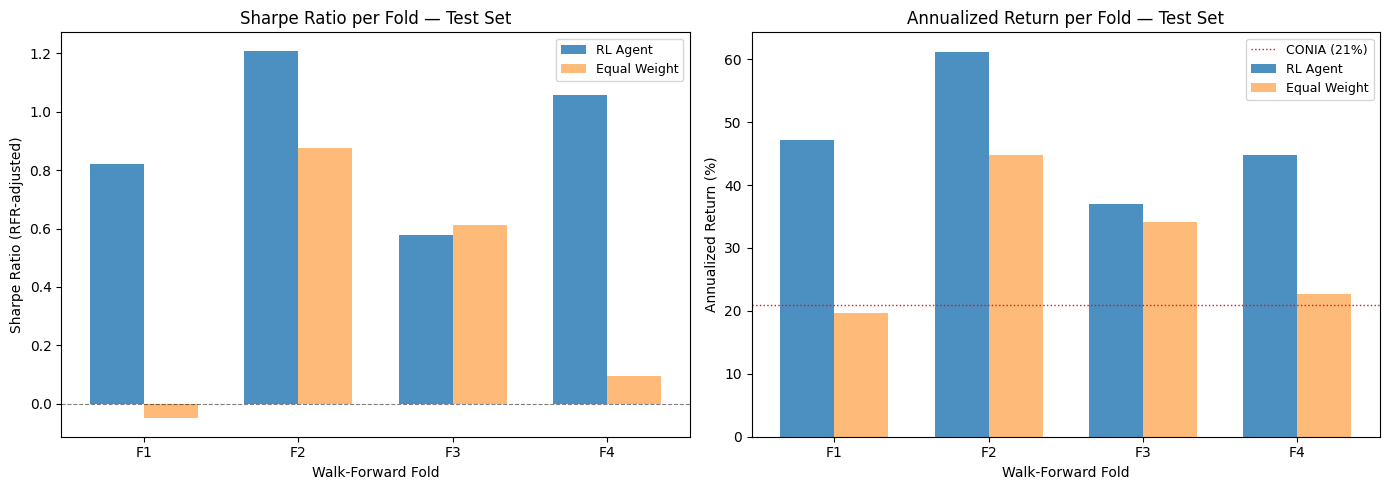


✅ Aggregate results saved to C:\Users\youssef\Desktop\Portfolio_Personalization\outputs\balanced\v4\aggregate

── Final Summary ──
RL  mean Sharpe : +0.916 ± 0.239
EQW mean Sharpe : +0.383 ± 0.376
RL  mean return : +47.5%
EQW mean return : +30.3%
RL significantly outperforms EQW   : 3/4 folds
RL significantly underperforms EQW : 0/4 folds


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

folds_list  = list(all_fold_results.keys())
rl_sharpes  = [all_fold_results[f]["rl_test"]["sharpe"]     for f in folds_list]
eq_sharpes  = [all_fold_results[f]["eq_test"]["sharpe"]     for f in folds_list]
rl_returns  = [all_fold_results[f]["rl_test"]["ann_return"] * 100 for f in folds_list]
eq_returns  = [all_fold_results[f]["eq_test"]["ann_return"] * 100 for f in folds_list]

x = np.arange(len(folds_list))
w = 0.35

ax = axes[0]
bars_rl = ax.bar(x - w/2, rl_sharpes, width=w, color=PALETTE["primary"],
                  alpha=0.85, label="RL Agent")
bars_eq = ax.bar(x + w/2, eq_sharpes, width=w, color=PALETTE["tertiary"],
                  alpha=0.85, label="Equal Weight")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Walk-Forward Fold")
ax.set_ylabel("Sharpe Ratio (RFR-adjusted)")
ax.set_title("Sharpe Ratio per Fold — Test Set")
ax.set_xticks(x)
ax.set_xticklabels([f.replace("fold_", "F") for f in folds_list])
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.bar(x - w/2, rl_returns, width=w, color=PALETTE["primary"],
        alpha=0.85, label="RL Agent")
ax2.bar(x + w/2, eq_returns, width=w, color=PALETTE["tertiary"],
        alpha=0.85, label="Equal Weight")
ax2.axhline(ANNUAL_RISK_FREE_RATE * 100, color=PALETTE["alert"],
            linewidth=1.0, linestyle=":", label=f"CONIA ({ANNUAL_RISK_FREE_RATE*100:.0f}%)")
ax2.set_xlabel("Walk-Forward Fold")
ax2.set_ylabel("Annualized Return (%)")
ax2.set_title("Annualized Return per Fold — Test Set")
ax2.set_xticks(x)
ax2.set_xticklabels([f.replace("fold_", "F") for f in folds_list])
ax2.legend(fontsize=9)

plt.tight_layout()
agg_plots_dir = BASE_DIR / "outputs" / RISK_PROFILE / VERSION / "aggregate"
agg_plots_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(agg_plots_dir / "fold_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Save aggregate summary ────────────────────────────────────────────────────
agg_summary = {
    "n_folds":           len(WALK_FORWARD_FOLDS),
    "risk_profile":      RISK_PROFILE,
    "version":           VERSION,
    "market_signal":     meta.get("market_signal", "egx30_ma_ratio"),
    "folds":             [f["name"] for f in WALK_FORWARD_FOLDS],
    "rl_mean_sharpe":    float(np.mean(rl_sharpes)),
    "rl_std_sharpe":     float(np.std(rl_sharpes)),
    "eq_mean_sharpe":    float(np.mean(eq_sharpes)),
    "eq_std_sharpe":     float(np.std(eq_sharpes)),
    "rl_mean_return":    float(np.mean(rl_returns)),
    "eq_mean_return":    float(np.mean(eq_returns)),
    "n_outperforms":     int(n_outperforms),
    "n_underperforms":   int(n_underperforms),
}
json.dump(agg_summary,
          open(agg_plots_dir / "aggregate_summary.json", "w"), indent=2)

print(f"\n✅ Aggregate results saved to {agg_plots_dir.resolve()}")
print(f"\n── Final Summary ──")
print(f"RL  mean Sharpe : {agg_summary['rl_mean_sharpe']:+.3f} ± {agg_summary['rl_std_sharpe']:.3f}")
print(f"EQW mean Sharpe : {agg_summary['eq_mean_sharpe']:+.3f} ± {agg_summary['eq_std_sharpe']:.3f}")
print(f"RL  mean return : {agg_summary['rl_mean_return']:+.1f}%")
print(f"EQW mean return : {agg_summary['eq_mean_return']:+.1f}%")
print(f"RL significantly outperforms EQW   : "
      f"{n_outperforms}/{len(WALK_FORWARD_FOLDS)} folds")
print(f"RL significantly underperforms EQW : "
      f"{n_underperforms}/{len(WALK_FORWARD_FOLDS)} folds")

In [29]:
# For each fold, correlate regime signal with cash allocation
for fold_name, result in all_fold_results.items():
    split  = fold_split_indices[fold_name]
    model  = fold_models[fold_name]

    eval_env = PortfolioEnv(
        feature_tensor=feature_tensor, returns_tensor=returns_tensor,
        mask_tensor=mask_tensor, market_signal=market_signal,
        universe_indices=universe_indices, split_indices=split,
        risk_profile=RISK_PROFILE, feature_names=feature_names,
        mode="test", episode_length=EPISODE_LENGTH,
        rebalance_days=REBALANCE_DAYS, silent=True,
    )

    signals, cash_weights = [], []
    obs, _ = eval_env.reset()
    for _ in range(EPISODE_LENGTH):
        action, _ = model.predict(obs, deterministic=True)
        obs, _, _, truncated, info = eval_env.step(action)
        day_idx = eval_env.start_idx + (eval_env.current_step - 1) * REBALANCE_DAYS
        signals.append(float(market_signal[day_idx, 0]))
        cash_weights.append(info["current_weights"][-1])
        if truncated:
            break

    corr = np.corrcoef(signals, cash_weights)[0, 1]
    print(f"{fold_name}: signal↔cash correlation = {corr:+.3f}  "
          f"({'✓ using signal' if corr < -0.1 else '✗ not using signal'})")

fold_1: signal↔cash correlation = +0.046  (✗ not using signal)
fold_2: signal↔cash correlation = -0.453  (✓ using signal)
fold_3: signal↔cash correlation = -0.199  (✓ using signal)
fold_4: signal↔cash correlation = -0.078  (✗ not using signal)
